In [ ]:
## connect to github
!git clone https://github.com/LilySommerseth1/DAT490_Capstone_Combine
!ls /content/DAT490_Capstone_Combine/Data


Cloning into 'DAT490_Capstone_Combine'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 97 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 461.86 KiB | 3.85 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Combine  Draft


#Imports

In [ ]:
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

#Constants

In [ ]:
#list of combine drills that we test a players ability
DRILL_COLUMNS = ['40yd', 'vertical', 'bench', 'broad jump', '3cone', 'shuttle']

#columns that will be converted to numbers
NUMERIC_COLUMNS = ['year', 'to', 'in', 'rnd', 'career_length', 'pick', 'wav']

#list of positions we want to compare
POSITIONS_TO_COMPARE = ['WR', 'RB', 'CB']

#stats used to measure a players success in the NFL
NFL_SUCCESS_METRICS = ['wav', 'career_length', 'g', 'ap1', 'pb']

#converts month names to numbers
MONTH_TO_NUMBER = {'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7}

#these are columns we want to fill missing values with 0
COLUMNS_TO_FILL_ZERO = [
    '40yd', 'vertical', 'bench', 'broad jump', '3cone', 'shuttle',
    'ap1', 'pb', 'st', 'wav', 'drav', 'g', 'cmp', 'att', 'yds',
    'td', 'int', 'att.1', 'yds.1', 'td.1', 'rec', 'yds.2',
    'td.2', 'solo', 'int.1', 'sk'
]

#list of metrics used for draft
DRAFT_METRICS = ['pick', 'rnd']

#Data Loading Function

In [ ]:
def load_and_concat_csv(directory_path, dataset_name):
    """
    load all CSV files from a directory and concatenate them into a single df

    arguments -
      diretory_path : the path to directory containing the csv
      dataset_name : the name of the dataset

    return -
      pandas.DataFrame: concatenated df of all CSV files
  """
    #get all csv in the directory
    csv_files = glob.glob(directory_path)
    #load all csv into df
    dataframes = [pd.read_csv(file) for file in csv_files]
    #concatenate all df
    result_df = pd.concat(dataframes, ignore_index=True)

    #prints the information about the dataset
    print("+" * 50)
    print(f"Dataset: {dataset_name}") #prints the dataset name
    print(f"df Shape: {result_df.shape}") #print number of rows and columns
    print("Columns:")
    print("-" * 50)

    #prints each column name with a number
    for idx, col in enumerate(result_df.columns):
        print(f"{idx+1}: {col}")
    print("+" * 50)

    #return the combine dataframe
    return result_df

#Data Processing Functions

In [ ]:
def standardize_dataframe(df):
    """
    cleans up the dataframe by fixing column names and key values like "player" and "year".
    makes things consistent for future steps

    arugments -
      df : the dataframe we want to standardize

    return -
      pandas.DataFrame: the standardized dataframe
    """
    #standardize column names - make column names all lowercase and remove any extra space
    df.columns = df.columns.str.strip().str.lower()

    #if player column exists in the df, clean up spacing and capitalizaiton
    if 'player' in df.columns:
        df['player'] = df['player'].str.strip().str.title()

    #if year column exists, convert it to a string and remove white spaces
    if 'year' in df.columns:
        df['year'] = df['year'].astype(str).str.strip()

    return df

def convert_columns_to_numeric(df, columns):
    """
    changes specific columns to numbers
    any value that cant be converted becomes NaN

    arguments -
      df : the dataframe you want to update
      columns : a list of column names you want to turn into numbers

    return -
      pandas.DataFrame: the updated dataframe with columns converted to numbers
    """

    for col in columns:
        if col in df.columns:
            #try to convert column to numbers; if it cant, use NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

def process_height_data(df):
    """
    splits the ht column into feet and inches, and fixes weird cases (like 'Jun' instead of 6'0")

    arguments -
      df: the dataframe that has the height column

    return -
      pandas.DataFrame: the updated dataframe with height in meters
    """
    #split the 'ht' columns into 'in' and 'ft'
    temp = pd.DataFrame()
    temp[['in', 'ft']] = df['ht'].str.split('-', expand=True)

    #map month names like 'Jun' to numbers
    temp['ft'] = temp['ft'].map(MONTH_TO_NUMBER).astype('Int64')

    #if inches column says 'Jun', fix it to 6 feet and 0 inches
    temp['ft'] = temp.apply(lambda row: 6 if row['in'] == 'Jun' else row['ft'], axis=1)
    temp['in'] = temp.apply(lambda row: 0 if row['in'] == 'Jun' else row['in'], axis=1)

    #convert column from type object to numeric
    temp['ft'] = pd.to_numeric(temp['ft'])
    temp['in'] = pd.to_numeric(temp['in'])

    #convert ft and in to meters
    df['ht'] = temp['ft'] * 0.3048 + temp['in'] * 0.0254

    return df

#Visualization Functions

In [ ]:
def create_subplot_grid(rows, cols, figsize=(15, 8)):
    """
    create a grid of subplots that we can use to show multiple charts on one figure

    arguments -
      rows : the number of rows in the grid
      cols : the number of columns in the grid
      figsize : the size of the figure

    return -
      tuple: a tuple containing the figure and an array of axes objects
    """
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    return fig, axes.flatten()

def create_drill_histograms(df, drill_columns, axes):
    """
    makes a histogram (with smooth curve) for each combine drill to show its distribution.

    arguments -
      df: the dataframe that holds the data
      drill_columns: our list of combine drills
      axes: the array of axes objects

    return -
      none: it draws the historgram on the given axes

    """
    for i, drill in enumerate(drill_columns):
        #plot the histogram with KDE curve on the matching subplot
        sns.histplot(df[drill].dropna(), kde=True, ax=axes[i])
        #add labels and title to the plot
        axes[i].set_title(f'Distribution of {drill.title()}')
        axes[i].set_xlabel(f'{drill.title()}')
        axes[i].set_ylabel('Frequency')

def create_drill_boxplots(df, drill_columns, axes, position_order):
    """
    makes a boxplot for each drill, comparing how players from different positions perform

    arguments -
      df: the dataframe that holds the data
      drill_columns: our list of combine drills
      axes: the array of axes objects
      position_order: our list of positions we want to compare

    return -
      none: just draws boxplots for each drill metric on the axes
    """
    for i, drill in enumerate(drill_columns):
        #create boxplot grouped by position
        sns.boxplot(x='pos_combine', y=drill, data=df, ax=axes[i], order=position_order)
        axes[i].set_title(f'{drill.title()} by Position')
        axes[i].set_xlabel('Position')
        axes[i].set_ylabel(drill.title())
        #rotate x-axis labels so they dont overlap
        axes[i].tick_params(axis='x', rotation=45)

def plot_drill_vs_career(df, drill_columns, positions, axes):
    """
    plots each drill score against average career length, broken down by position

    arguments -
      df: the dataframe that holds the data
      drill_columns: our list of combine drills
      positions: our list of positions we want to compare
      axes: the array of axes objects

    return -
      none: it plots average career length vs. drill performance for each position
    """
    for i, drill in enumerate(drill_columns):
        #get the subplot axis to draw on
        ax = axes[i]
        for pos in positions:
            #filter the data for the current position
            subset = df[df['pos_combine'] == pos].copy()
            #keep only rows where the drill score and career length are both greater than 0
            subset = subset[(subset[drill] > 0) & (subset['career_length'] > 0)]
            #group by the rounded drill value and get the average career length for each group
            avg_df = subset.groupby(subset[drill].round(1))['career_length'].mean().reset_index()
            #plot the average career length against the drill value for this position
            ax.plot(avg_df[drill], avg_df['career_length'], marker='o', label=pos)

        #set the title and labels for the current plot
        ax.set_title(f'{drill.title()} vs. Career Length')
        ax.set_xlabel(f'{drill.title()}')
        ax.set_ylabel('Avg Career Length (Years)')

        #add grid lines and legend
        ax.grid(True)
        ax.legend(title='Position', loc='upper right')

def create_correlation_heatmap(df, columns, title, figsize=(10, 8)):
    """
    creates a heatmap showing how strongly each column is correlated

    arguments -
      df: the dataframe that holds the data
      columns: a list of columns to include
      title: the title of the heatmap
      figsize: the size of the figure

    return -
      none: it draws the heatmap
    """
    #calculate correlation matrix
    corr_matrix = df[columns].corr()

    #set figure size and draw heatmap with colored values
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def create_correlation_subplot(df, x_cols, y_cols, title, figsize=(12, 10)):
    """
    makes a heatmap showing correlation between two groups of columns

    arugments -
      df: the dataframe that holds the data
      x_cols: a list of columns to include in the x-axis
      y_cols: a list of columns to include in the y-axis
      title: the title of the figure
      figsize: the size of the figure

    return -
      none: it draws the heatmap
    """
    #compute correlatio nfor all selected columns
    correlation_matrix = df[x_cols + y_cols].corr()

    #plot only the correlation between x_cols and y_cols
    plt.figure(figsize=figsize)
    sns.heatmap(correlation_matrix.loc[x_cols, y_cols],
                annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

def run_pca_analysis(df, columns, n_components=2):
    """
    run PCA on selected columns to reduce dimensions

    arguments -
      df: the dataframe that holds the data
      columns: the columns to include in the PCA
      n_components: how many principal components to create

    return -
      tuple: a tuple containing the PCA dataframe and the PCA object
    """
    #remove rows with missing values in the selected columns
    pca_df = df.dropna(subset=columns)

    #scale the data so all columns have similar weight
    scaler = StandardScaler()
    X = scaler.fit_transform(pca_df[columns])

    #run PCA to reduce the number of dimensions
    pca = PCA(n_components=n_components)
    components = pca.fit_transform(X)

    #add each principal component as a new column in the df
    for i in range(n_components):
        pca_df[f'PC{i+1}'] = components[:, i]

    return pca_df, pca

def plot_position_metric_correlations(df, target_col, drill_columns, positions=None,
                                      min_position_count=30, min_samples=10,
                                      title=None, figsize=(14, 10)):
    """
    plots a heatmap of correlations between combine drills and a target column (e.g., WAV or pick)
    across different positions.

    arguments -
        df: The input DataFrame
        target_col: The column to correlate against
        drill_columns: List of metric columns to include
        min_position_count: Minimum number of players a position must have to be considered
        min_samples: Minimum number of valid samples to compute correlation
        title: Title of the heatmap
        figsize: Size of the heatmap plot

    Returns:
        None
    """
    #exclude kicker and punter
    df = df[~df['pos_combine'].isin(['K', 'P'])]

    if positions is None:
      #count how many players are in each position
      position_counts = df['pos_combine'].value_counts()
      #keep only positions that have at least 30 players
      common_positions = position_counts[position_counts >= min_position_count].index.tolist()
      group_col = 'pos_combine'
    else:
      #use the provided positions
      common_positions = positions
      group_col = 'position_group'

    #dictionary to store correlation values for each position
    position_correlations = {}

    #loop through each common position
    for pos in common_positions:
        #get data for this specific position
        pos_data = df[df[group_col] == pos]

        #make sure we have at least 10 players for a stable correlation
        if pos_data.shape[0] >= min_samples:
            #select just the drill columns and target column
            temp_df = pos_data[drill_columns + [target_col]]

            #calculate the full correlation matrix
            corr_matrix = temp_df.corr()
            #if the target column is present, extract its correlations with the drills
            if target_col in corr_matrix:
                corr_series = corr_matrix[target_col][drill_columns]
                #store the correlations for this position
                position_correlations[pos] = corr_series.to_dict()

    #convert the dictionary of correlations to a df
    corr_df = pd.DataFrame(position_correlations).T
    #rop positions where all correlation values are NaN
    corr_df = corr_df.dropna(how='all')

    # Plot heatmap
    plt.figure(figsize=figsize)
    #create the heatmap with correlation values
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)
    #set title and axis labels
    plt.title(title or f'Correlation between Combine Metrics and {target_col.upper()} by Position', fontsize=16)
    plt.xlabel('Combine Metrics', fontsize=14)
    plt.ylabel('Position', fontsize=14)
    plt.tight_layout()
    plt.show()

#Load Datasets

In [ ]:
#load and combine all csv files from the combine folder into one dataframe
combine_df = load_and_concat_csv('/content/DAT490_Capstone_Combine/Data/Combine/*.csv', 'Combine')
#load and combine all csv files from the draft folder into one dataframe
draft_df = load_and_concat_csv('/content/DAT490_Capstone_Combine/Data/Draft/*.csv', 'Draft')

++++++++++++++++++++++++++++++++++++++++++++++++++
Dataset: Combine
df Shape: (7835, 13)
Columns:
--------------------------------------------------
1: Player
2: Pos
3: School
4: Year
5: Ht
6: Wt
7: 40yd
8: Vertical
9: Bench
10: Broad Jump
11: 3Cone
12: Shuttle
13: Drafted (tm/rnd/yr)
++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++
Dataset: Draft
df Shape: (6412, 29)
Columns:
--------------------------------------------------
1: Rnd
2: Pick
3: Tm
4: Player
5: Pos
6: Age
7: To
8: AP1
9: PB
10: St
11: wAV
12: DrAV
13: G
14: Cmp
15: Att
16: Yds
17: TD
18: Int
19: Att.1
20: Yds.1
21: TD.1
22: Rec
23: Yds.2
24: TD.2
25: Solo
26: Int.1
27: Sk
28: College/Univ
29: Year
++++++++++++++++++++++++++++++++++++++++++++++++++


#Merge Datasets and Clean Data

In [ ]:
#clean up column names and key fields in the combine dataset
combine_df = standardize_dataframe(combine_df)
#clean up column names and key fields in the draft dataset
draft_df = standardize_dataframe(draft_df)

#merge the combine and draft datasets using "player" and "year" as keys (inner join)
#adds suffixes to tell columns apart if they exist in both datasets
merged_df = pd.merge(combine_df, draft_df, on=['player', 'year'], how='inner', suffixes=('_combine', '_draft'))

#split columns ht into feet and inches and clen weird entries
merged_df = process_height_data(merged_df)

#drop rows where important values (player name, weight, height) are missing
critical_columns = ['player', 'wt', 'ht']
merged_df = merged_df.dropna(subset=critical_columns)

#drop columns that are not needed or have repeated info
duplicate_columns = ['drafted (tm/rnd/yr)', 'college/univ']
merged_df = merged_df.drop(columns=duplicate_columns)

#convert all specified columns to numbers
merged_df = convert_columns_to_numeric(merged_df, NUMERIC_COLUMNS + DRILL_COLUMNS)

#fill missing ages with the median age
merged_df['age'] = merged_df['age'].fillna(merged_df['age'].median())

#if a player's "to" year (last season) is missing, use their draft year
#this means they were drafted but never played in the NFL
merged_df["to"] = merged_df["to"].fillna(merged_df["year"])

#create a new column showing how many years the player had a career
merged_df["career_length"] = merged_df["to"] - merged_df["year"]

#for all columns we want to treat as "0 if missing", fill missing values with 0
existing_columns = [col for col in COLUMNS_TO_FILL_ZERO if col in merged_df.columns]
merged_df[existing_columns] = merged_df[existing_columns].fillna(0)

#show the first few rows of the cleaned dataset
merged_df.head()

,player,pos_combine,school,year,ht,wt,40yd,vertical,bench,broad jump,...,att.1,yds.1,td.1,rec,yds.2,td.2,solo,int.1,sk,career_length
0,Keith Adams,OLB,Clemson,2001.0,1.8034,219.0,4.82,0.0,24.0,104.0,...,0.0,0.0,0.0,0.0,0.0,0.0,147.0,0.0,0.0,6.0
1,Hakim Akbar,S,Washington,2001.0,1.8288,210.0,4.55,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0
2,Brian Allen,OLB,Florida State,2001.0,1.8288,238.0,4.65,0.0,25.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,74.0,1.0,1.0,3.0
3,Will Allen,CB,Syracuse,2001.0,1.7780,192.0,4.44,39.5,14.0,121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,460.0,15.0,5.0,10.0
4,Scotty Anderson,WR,Grambling State,2001.0,1.8796,184.0,4.57,34.5,0.0,115.0,...,0.0,0.0,0.0,54.0,858.0,4.0,0.0,0.0,0.0,2.0


In [ ]:
merged_df.shape

(4830, 39)

#Analysis DataFrame


In [ ]:
analysis_df = merged_df.copy()

# Replace zeros with NaN for combine metrics
for metric in DRILL_COLUMNS:
    analysis_df[metric] = analysis_df[metric].replace(0, np.nan)

#Analysis Describe

In [ ]:
#show summary statistics
analysis_df.describe()

,year,ht,wt,40yd,vertical,bench,broad jump,3cone,shuttle,rnd,...,att.1,yds.1,td.1,rec,yds.2,td.2,solo,int.1,sk,career_length
count,4830.000000,4830.000000,4830.000000,4580.000000,3801.000000,3281.000000,3750.000000,3074.000000,3136.000000,4830.000000,...,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000,4830.000000
mean,2010.997101,1.878043,245.322567,4.750594,33.287766,21.444377,115.385600,7.256057,4.379190,3.886335,...,47.811180,203.557971,1.473913,34.915528,399.752795,2.440580,70.668944,1.386542,3.878986,4.496894
std,6.579428,0.066626,45.599469,0.301118,4.172270,6.419200,9.326484,0.404911,0.261444,1.939475,...,222.286137,964.687247,7.223386,109.260626,1354.501922,8.891705,134.368669,4.247454,12.434912,3.381257
min,2000.000000,1.651000,155.000000,4.220000,20.500000,2.000000,83.000000,6.280000,3.730000,1.000000,...,0.000000,-21.000000,0.000000,0.000000,-16.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2005.000000,1.828800,207.000000,4.510000,30.500000,17.000000,109.000000,6.950000,4.180000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,2011.000000,1.879600,236.000000,4.660000,33.500000,21.000000,117.000000,7.160000,4.340000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,4.000000
75%,2017.000000,1.930400,288.750000,4.950000,36.000000,26.000000,122.000000,7.520000,4.550000,6.000000,...,0.000000,0.000000,0.000000,1.000000,9.000000,0.000000,77.000000,0.000000,1.000000,7.000000
max,2022.000000,2.057400,384.000000,5.990000,46.000000,49.000000,147.000000,9.000000,5.220000,7.000000,...,3735.000000,16000.000000,120.000000,1432.000000,17492.000000,121.000000,1111.000000,51.000000,159.500000,22.000000


#Position Distribution Plot

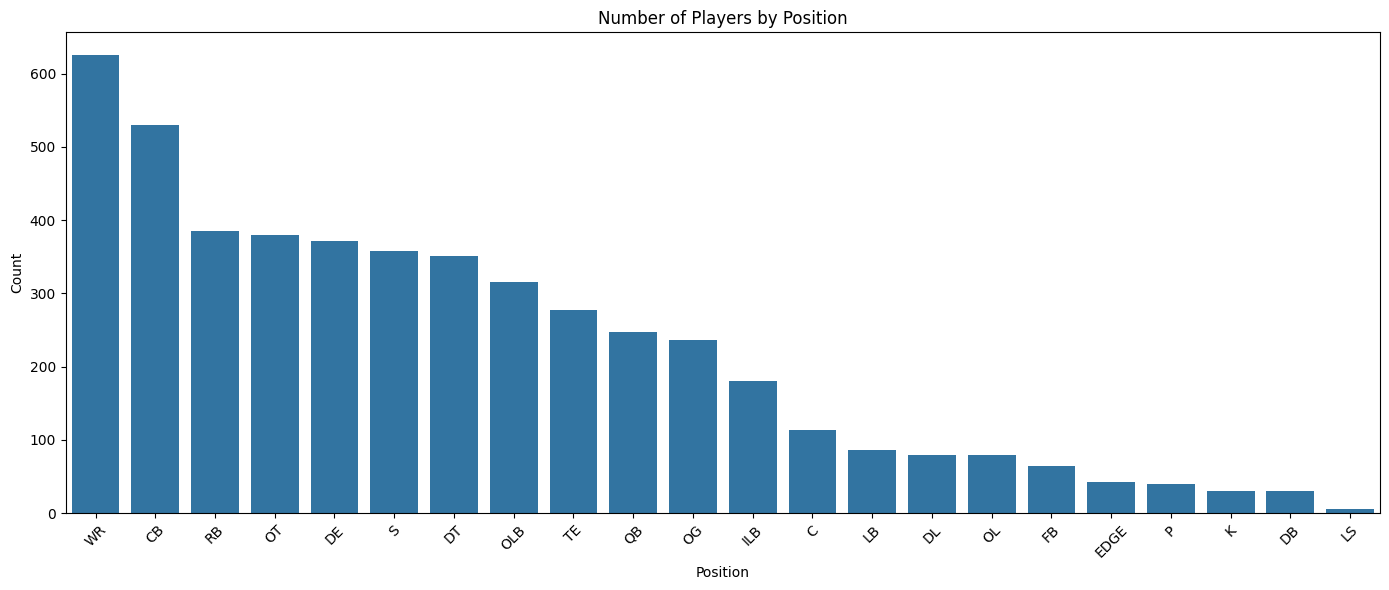

In [ ]:
#set the size of the figur
plt.figure(figsize=(14, 6))

#count how many players are in each position
position_counts = analysis_df['pos_combine'].value_counts()

#create the bar plot using the position names and their counts
sns.barplot(x=position_counts.index, y=position_counts.values)

#set the title of the chart
plt.title('Number of Players by Position')

#rotate the x-axis labels so they don’t overlap
plt.xticks(rotation=45)

#label the axes
plt.xlabel('Position')
plt.ylabel('Count')

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

#Drill Histograms

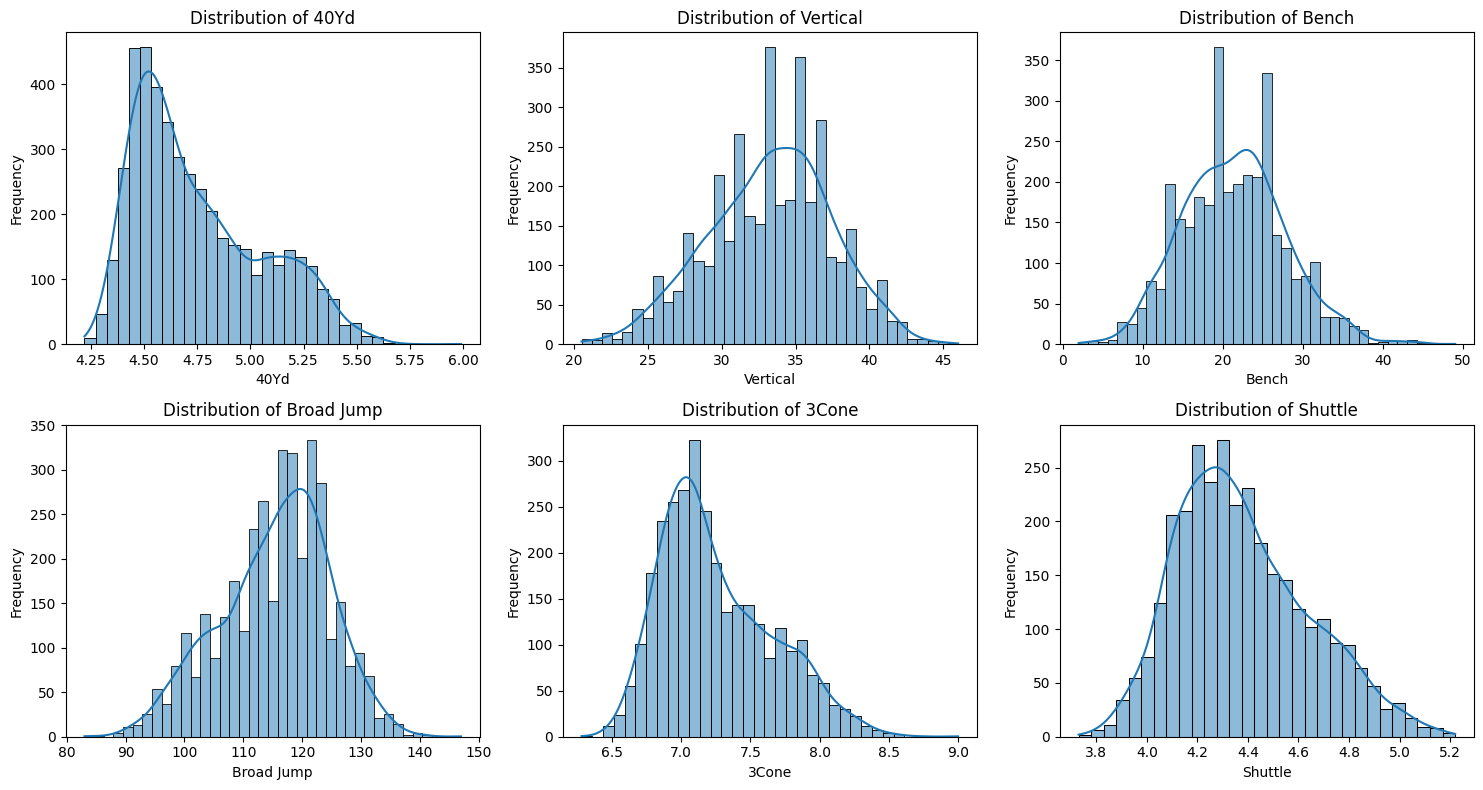

In [ ]:
#create a 2x3 grid of subplots and get a list of axes to draw on
fig, axes = create_subplot_grid(2, 3)

#plot histogram for each drill using the axes
create_drill_histograms(analysis_df, DRILL_COLUMNS, axes)

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

#Drill Boxplots by Position

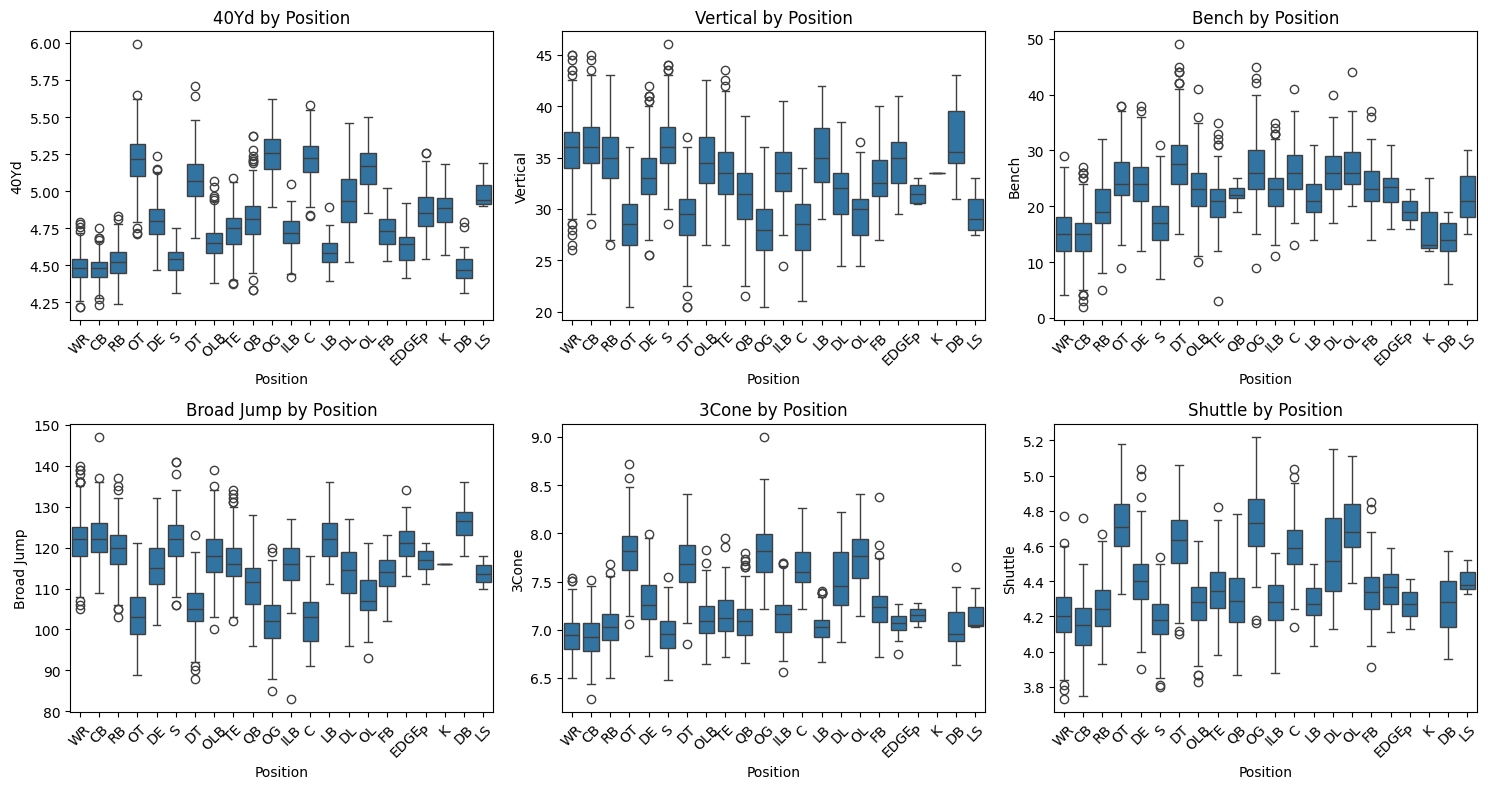

In [ ]:
#get the list of positions ordered by how many players are in each
position_order = analysis_df['pos_combine'].value_counts().index.tolist()

#create a 2x3 grid of subplots and get the axes to plot on
fig, axes = create_subplot_grid(2, 3)

#create a boxplot for each drill, grouped by position, using the ordered list
create_drill_boxplots(analysis_df, DRILL_COLUMNS, axes, position_order)

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

#Drill Metrics vs Career Length

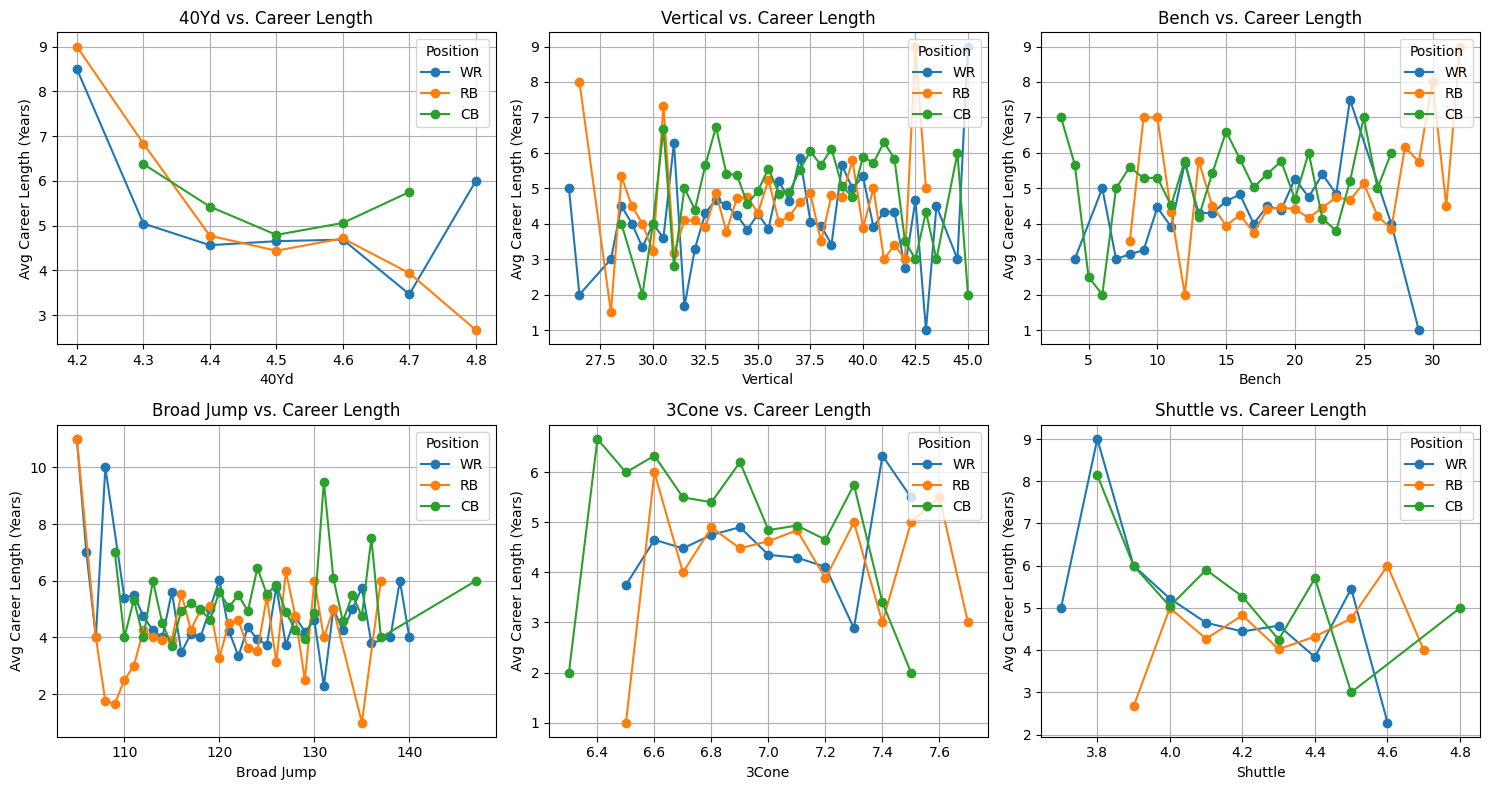

In [ ]:
#create a 2x3 grid of subplots and get the axes to plot on
fig, axes = create_subplot_grid(2, 3)

#for each drill, plot how it relates to average career length across selected positions
plot_drill_vs_career(analysis_df, DRILL_COLUMNS, POSITIONS_TO_COMPARE, axes)

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

#Draft Round Distribution

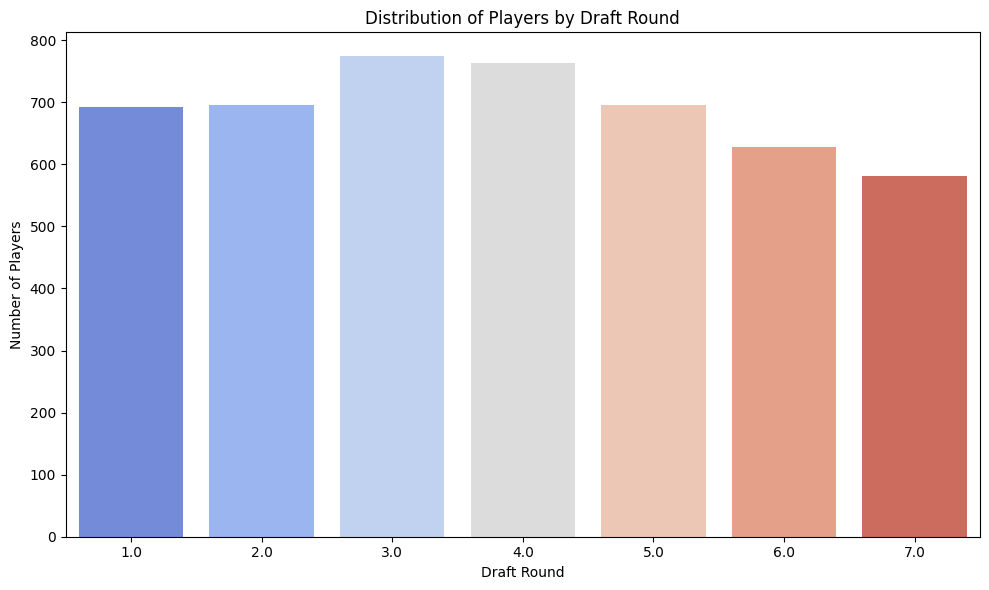

In [ ]:
#set the size of the plot
plt.figure(figsize=(10, 6))

#create a bar chart showing the number of players per draft round
sns.countplot(x='rnd', data=analysis_df, palette='coolwarm')

#set the title of the chart
plt.title('Distribution of Players by Draft Round')

#label the x and y axes
plt.xlabel('Draft Round')
plt.ylabel('Number of Players')

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

#Correlation Heatmap for Drill Metrics

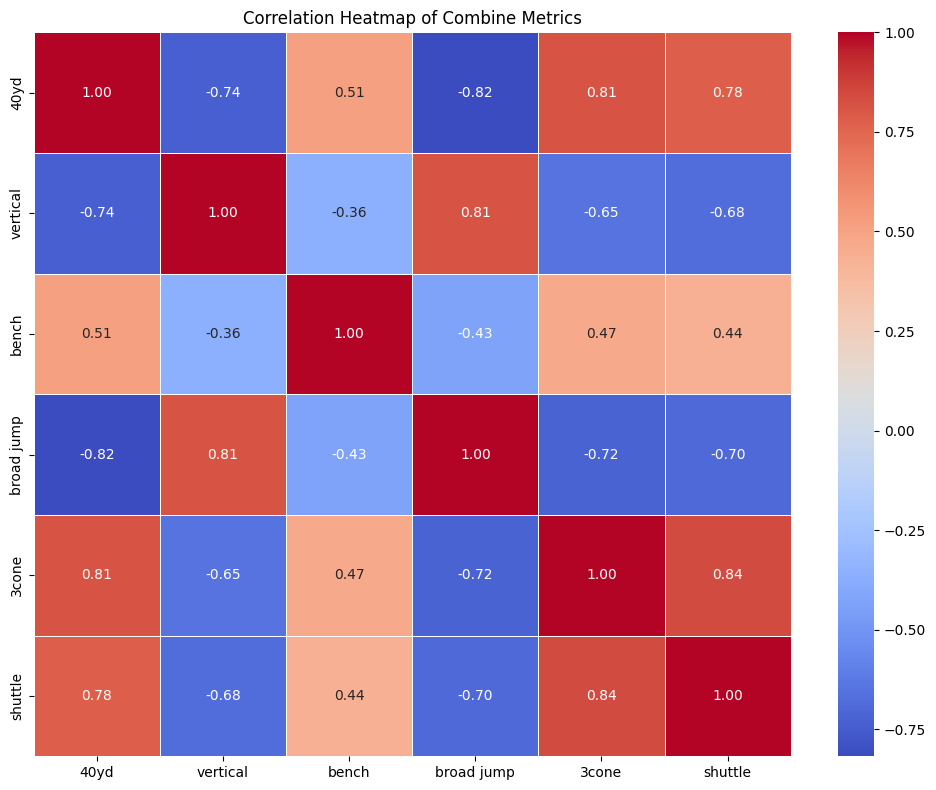

In [ ]:
#create correlation heatmap for drill metrics
create_correlation_heatmap(analysis_df, DRILL_COLUMNS, 'Correlation Heatmap of Combine Metrics')

#Correlation between Combine Metrics and Draft Position

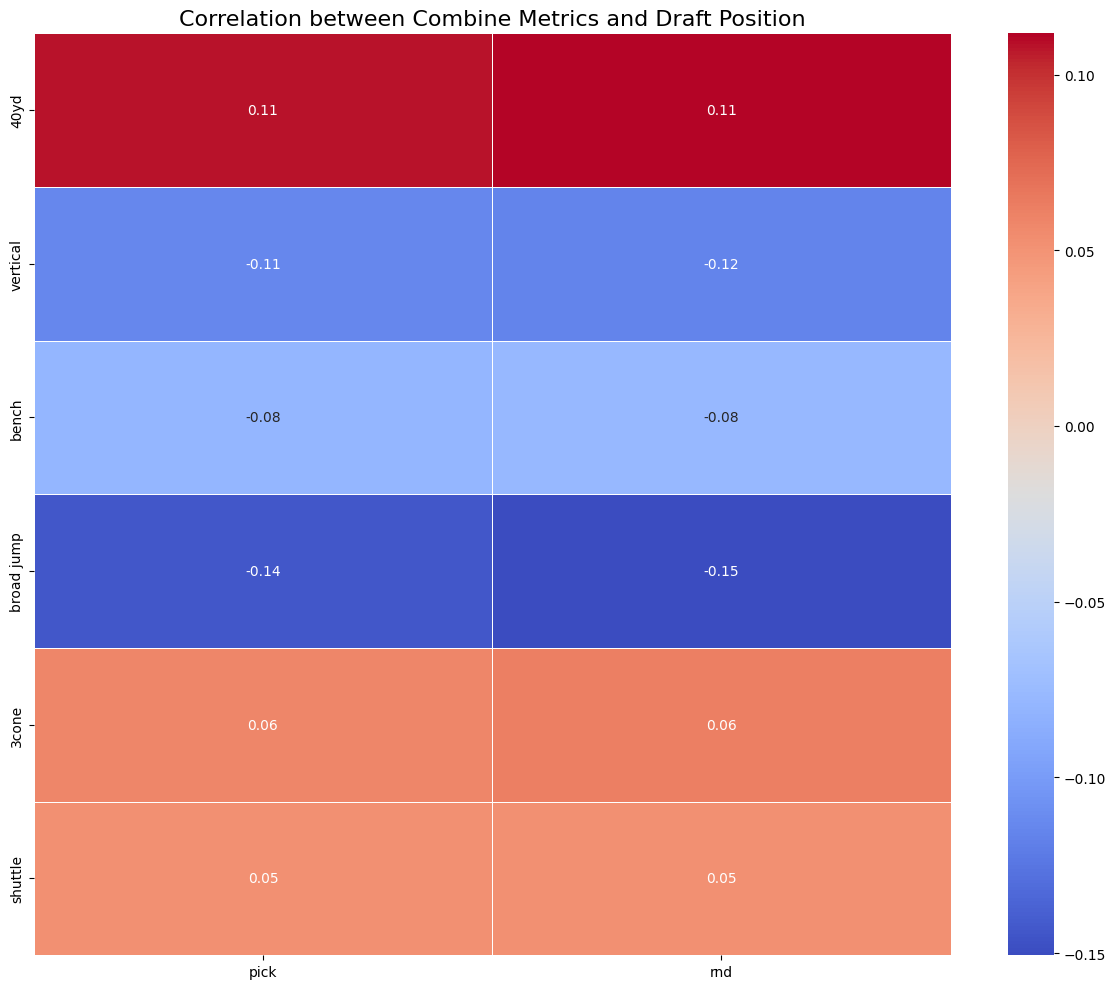

In [ ]:
#create a heatmap showing how combine drill scores relate to draft metrics
create_correlation_subplot(analysis_df, DRILL_COLUMNS, DRAFT_METRICS, 'Correlation between Combine Metrics and Draft Position', (12, 10))

#Boxplots of Metrics by Draft Round

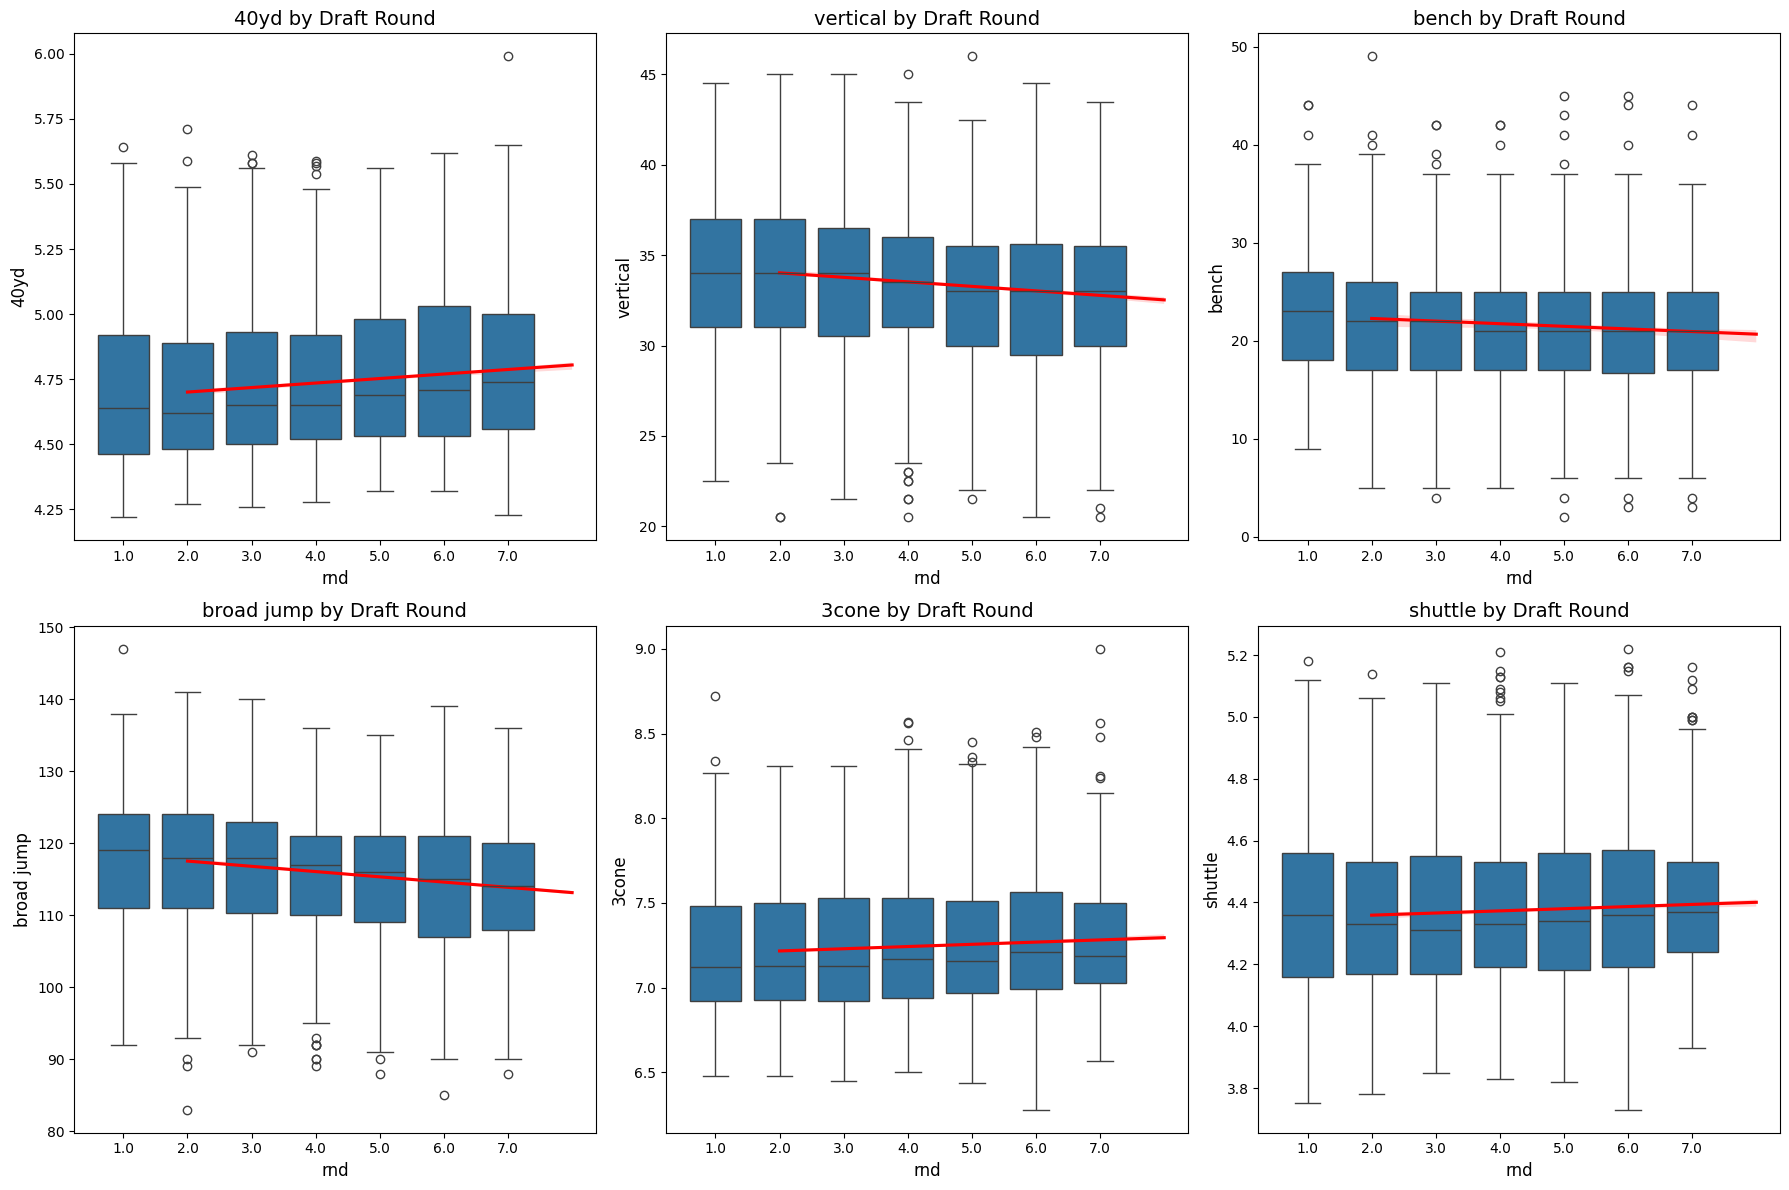

In [ ]:
plt.figure(figsize=(18, 12))
#loop through each drill metric and its index
for i, metric in enumerate(DRILL_COLUMNS, 1):
    #reate a 2-row, 3-column grid of subplots and select the current one
    plt.subplot(2, 3, i)

    #ilter the data to include only valid draft rounds (1–7) and non-missing values for this drill
    valid_data = analysis_df[(analysis_df['rnd'] >= 1) &
                             (analysis_df['rnd'] <= 7) &
                             (~analysis_df[metric].isna())]

    #create a boxplot showing the distribution of the drill scores by draft round
    sns.boxplot(x='rnd', y=metric, data=valid_data)

    #set title and axis labels
    plt.title(f'{metric} by Draft Round', fontsize=14)
    plt.xlabel('Draft Round', fontsize=12)
    plt.ylabel(metric, fontsize=12)

    #calculate the average drill score per round
    round_means = valid_data.groupby('rnd')[metric].mean().reset_index()

    #if we have valid averages, plot a red trend line through them
    if not round_means.empty and len(round_means) > 1:
        sns.regplot(x='rnd', y=metric, data=round_means, scatter=False, color='red')

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

#Correlation between Combine Metrics and NFL Success

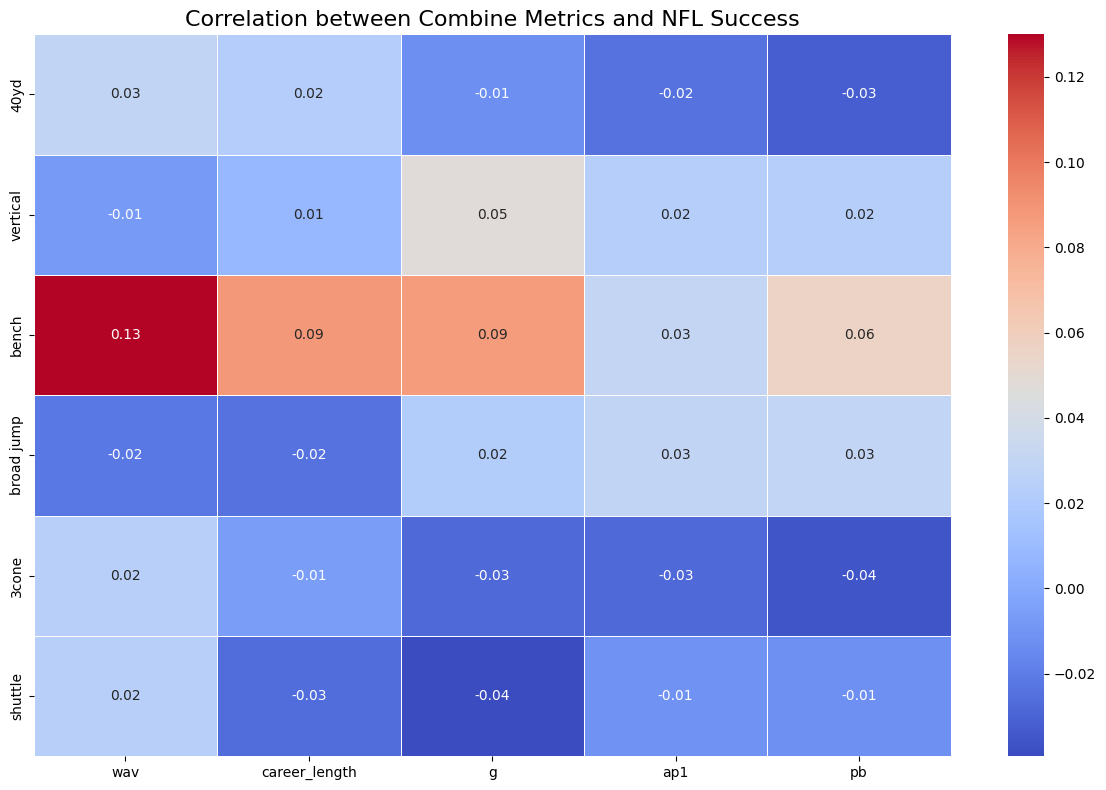

In [ ]:
#plot a heatmap showing how combine drill scores relate to NFL success metrics
create_correlation_subplot(analysis_df, DRILL_COLUMNS, NFL_SUCCESS_METRICS, 'Correlation between Combine Metrics and NFL Success',(12, 8))

#Position-Specific Correlations

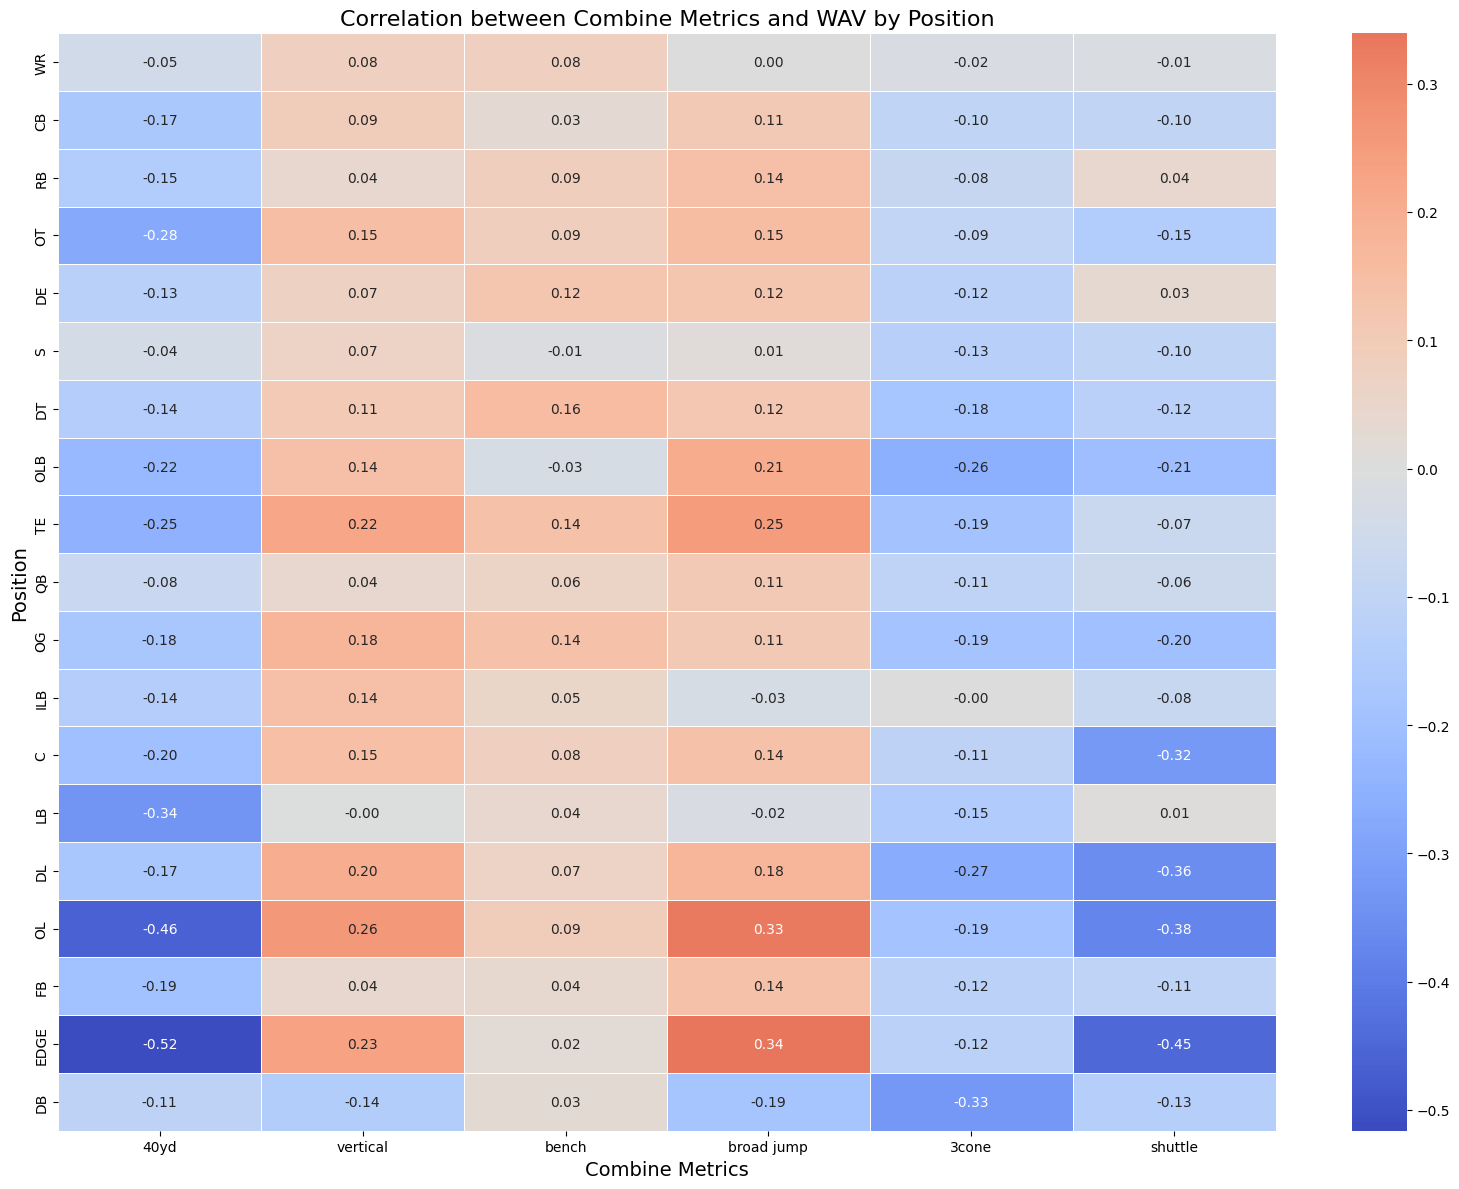

In [ ]:
#plot how combine drills correlate with WAV
plot_position_metric_correlations(
    analysis_df,
    target_col='wav',
    drill_columns=DRILL_COLUMNS,
    title='Correlation between Combine Metrics and WAV by Position',
    figsize=(16, 12)
)

#Pairplot

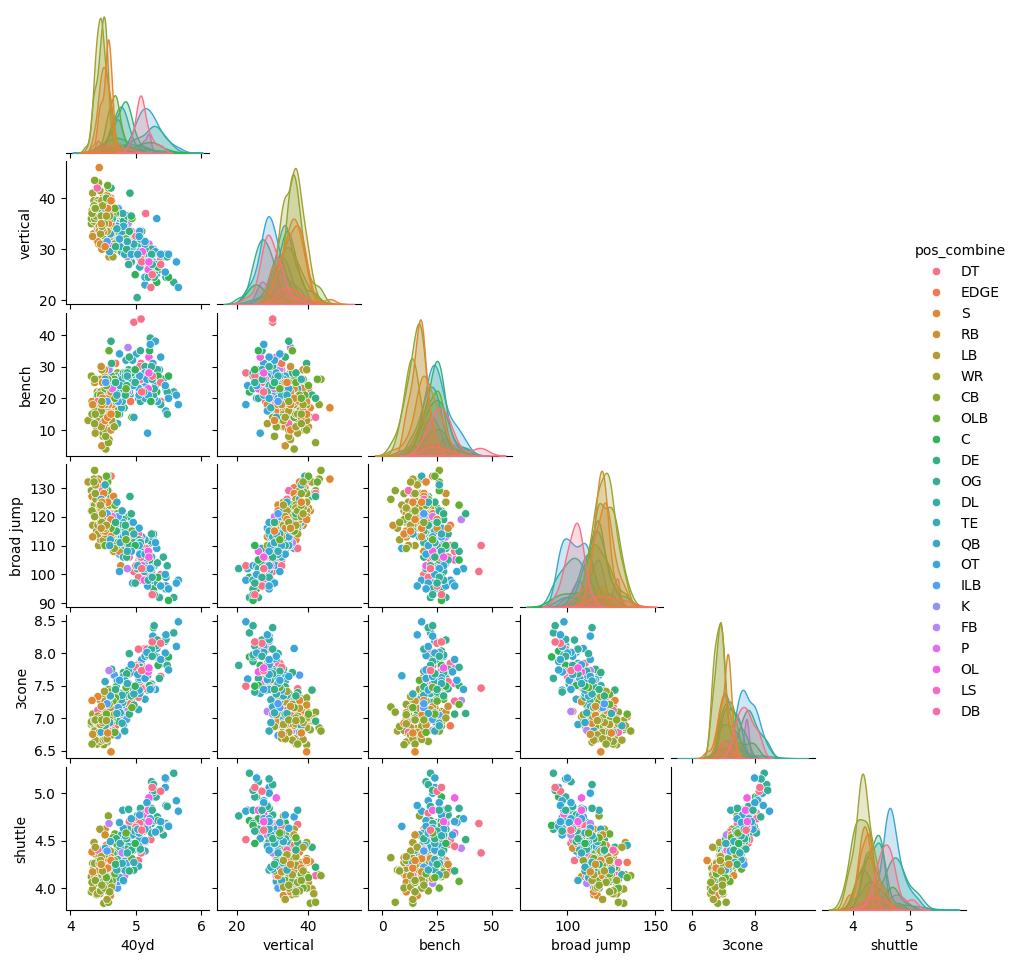

In [ ]:
#combine the list of drill columns with draft round and career length for filtering or analysis
all_cols = DRILL_COLUMNS + ['rnd', 'career_length']

#take a random sample of 500 rows from the dataset, including only drill metrics and position
sampled = analysis_df[DRILL_COLUMNS + ['pos_combine']].sample(n=500, random_state=42)
#create a pairplot to show relationships between drill metrics, colored by position
sns.pairplot(sampled, hue='pos_combine', corner=True)

#resize the entire plot to 10x10 inches
plt.gcf().set_size_inches(10, 10)
#adjust spacing around the plot to avoid cut-off labels or overlaps
plt.subplots_adjust(top=0.95, right=0.95, left=0.05, bottom=0.05)
#display the plot
plt.show()

#PCA Analysis

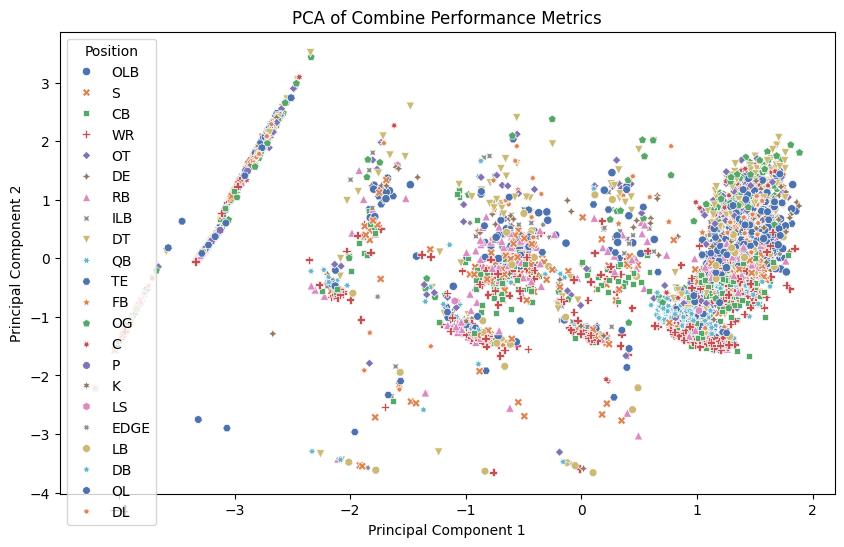

Explained variance ratio: [0.55079467 0.16606013]


In [ ]:
#run PCA on combine drill metrics
pca_df, pca = run_pca_analysis(merged_df, DRILL_COLUMNS)

#set the figure size
plt.figure(figsize=(10, 6))
#create a scatter plot using the two principal components
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='pos_combine', style='pos_combine', palette='deep')
#add title and axis labels
plt.title('PCA of Combine Performance Metrics')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
#show legend for positions
plt.legend(title='Position')
#display the plot
plt.show()

#print how much variance each principal component explains
print("Explained variance ratio:", pca.explained_variance_ratio_)

#Extended EDA


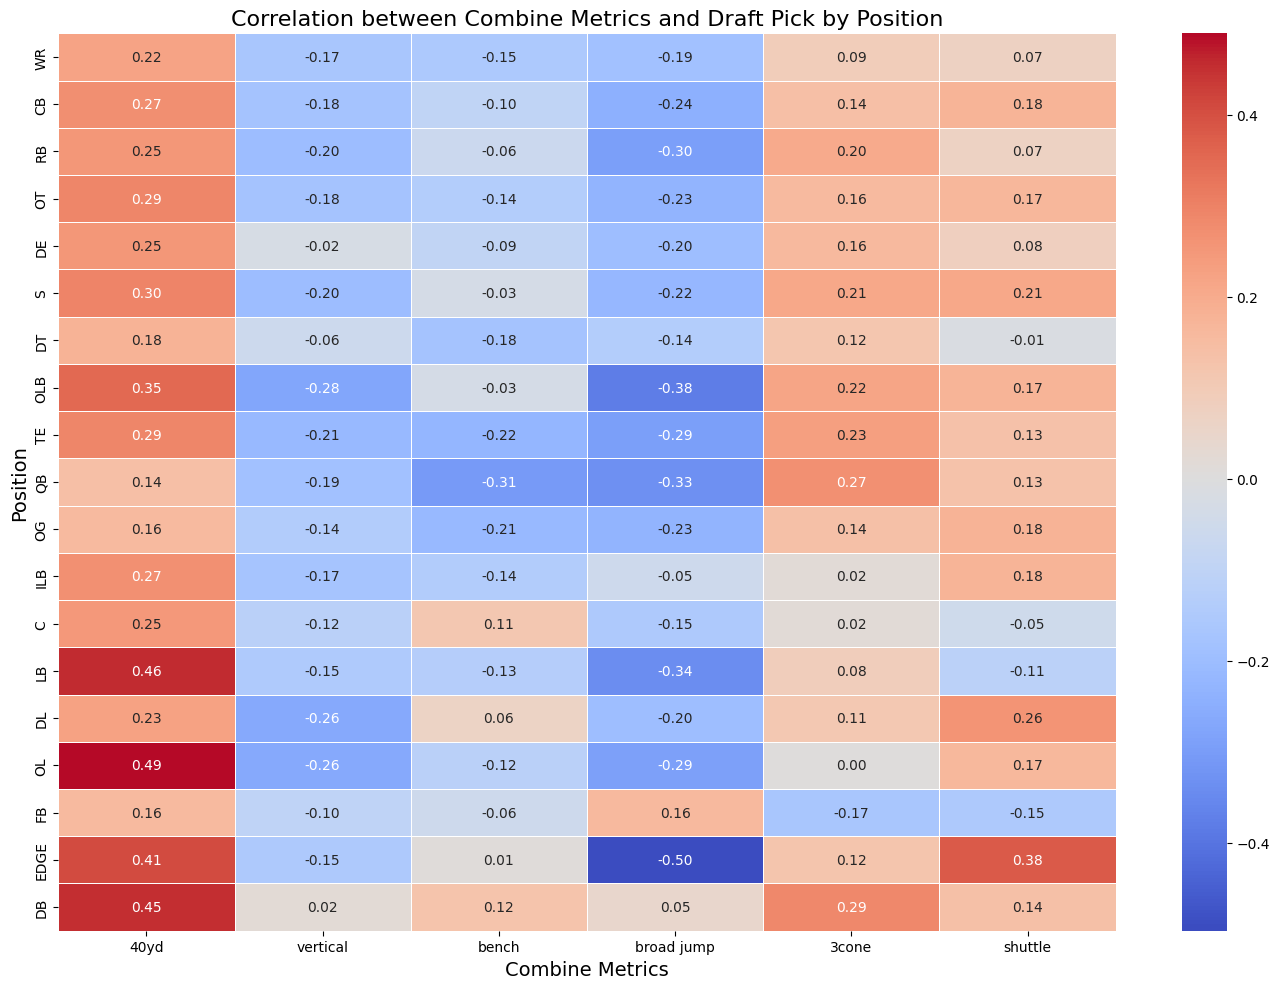

In [ ]:
# plot how combine drills correlate with draft pick
plot_position_metric_correlations(
    analysis_df,
    target_col='pick',
    drill_columns=DRILL_COLUMNS,
    title='Correlation between Combine Metrics and Draft Pick by Position',
    figsize=(14, 10)
)

In [ ]:
print(analysis_df['pos_combine'].unique())

['OLB' 'S' 'CB' 'WR' 'OT' 'DE' 'RB' 'ILB' 'DT' 'QB' 'TE' 'FB' 'OG' 'C' 'P'
 'K' 'LS' 'EDGE' 'LB' 'DB' 'OL' 'DL']


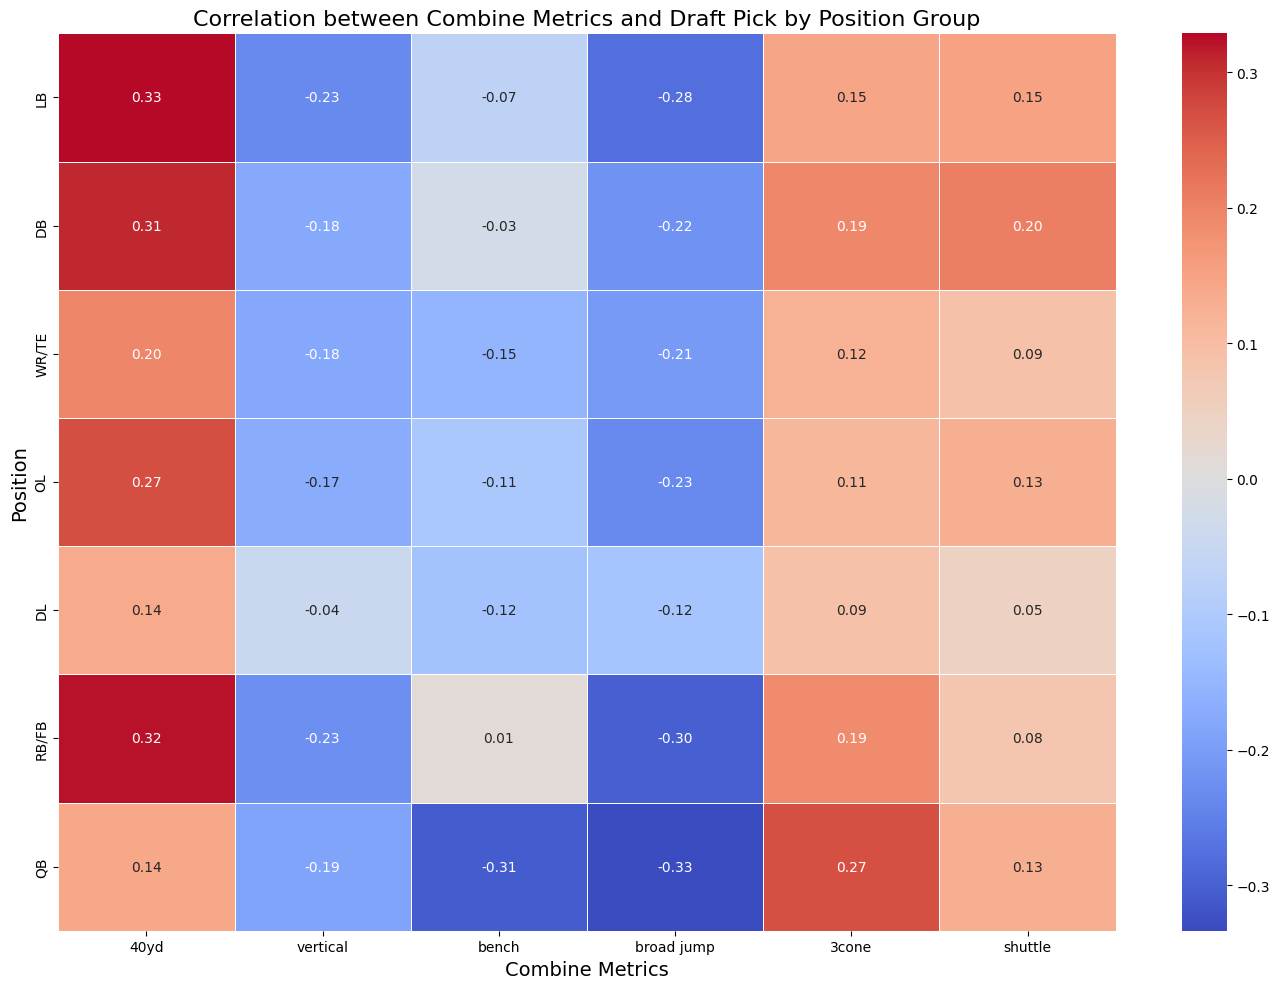

In [ ]:
#position groups by grouping similar positions together
position_groups = {
    'QB': ['QB'],
    'RB/FB': ['RB', 'FB'],
    'WR/TE': ['WR', 'TE'],
    'OL': ['OT', 'OG', 'C', 'OL'],
    'DL': ['DE', 'DT', 'DL', 'EDGE'],
    'LB': ['OLB', 'ILB', 'LB'],
    'DB': ['CB', 'S', 'FS', 'SS', 'DB']
}

#create a copy of the df
grouped_df = analysis_df.copy()

#create a new column called 'position_group' by mapping each position to its group
for group, position in position_groups.items():
    grouped_df.loc[grouped_df['pos_combine'].isin(position), 'position_group'] = group

#call the plotting function to see how combine metrics correlate with draft pick by grouped position
position_group_corr = plot_position_metric_correlations(
    grouped_df,
    target_col='pick',
    drill_columns=DRILL_COLUMNS,
    positions=list(grouped_df['position_group'].unique()),
    min_position_count=1,
    min_samples=1,
    title='Correlation between Combine Metrics and Draft Pick by Position Group',
    figsize=(14, 10)
)

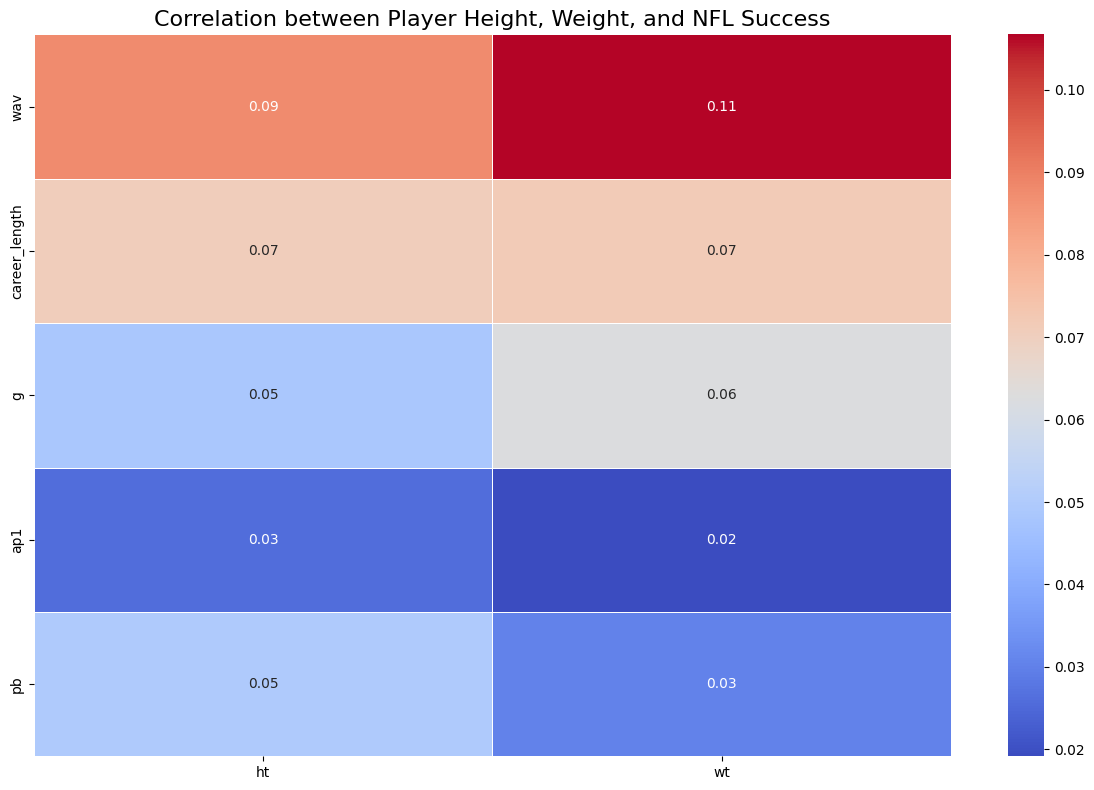

In [ ]:
#plot a heatmap showing how height and weight relate to NFL success metrics
create_correlation_subplot(analysis_df, NFL_SUCCESS_METRICS, ['ht', 'wt'], 'Correlation between Player Height, Weight, and NFL Success',(12, 8))

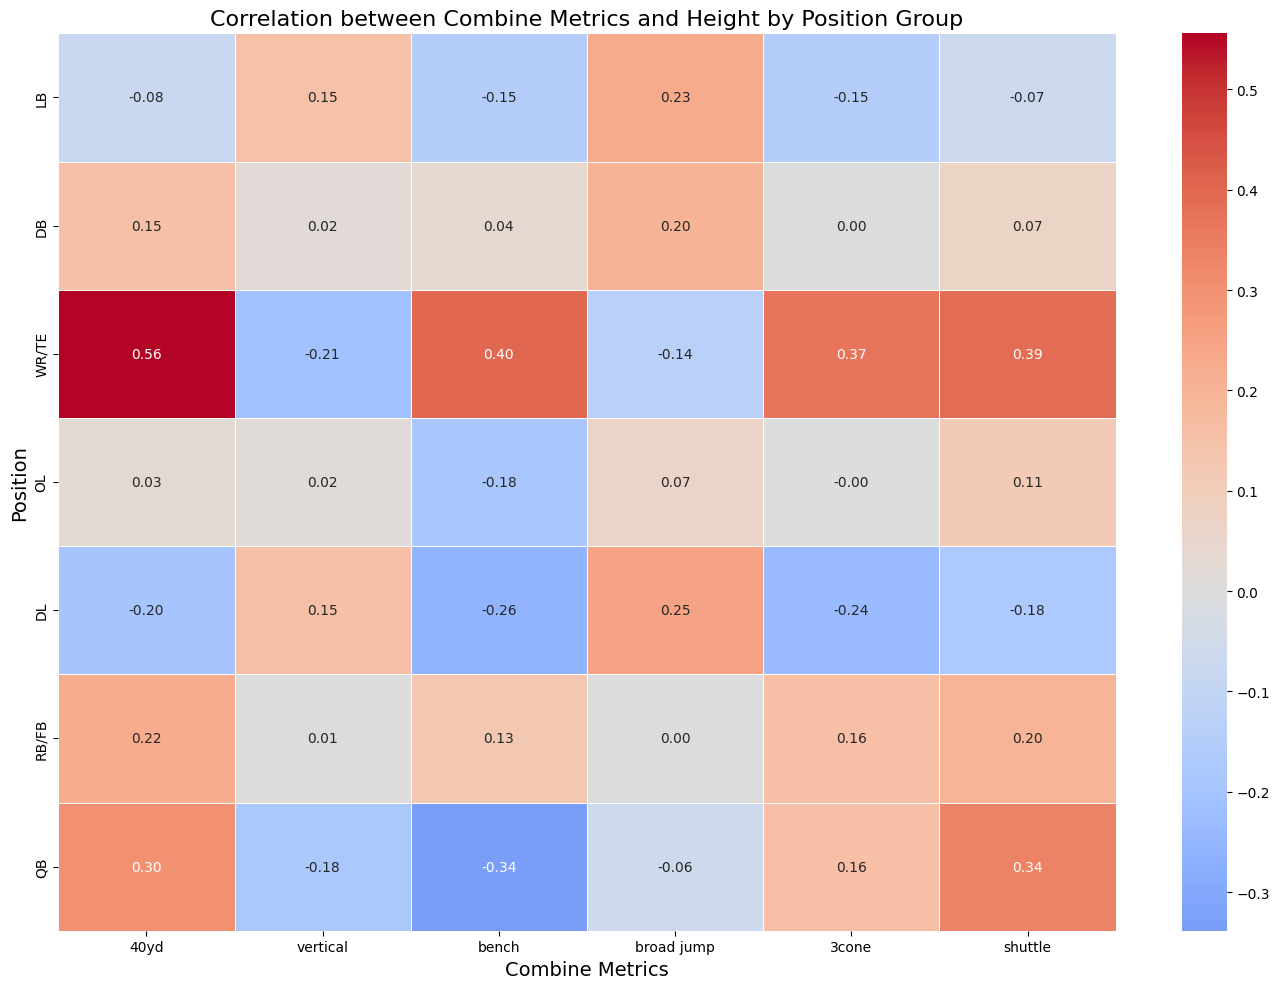

In [ ]:
#call the plotting function to see how combine metrics correlate with height by grouped position
position_group_corr = plot_position_metric_correlations(
    grouped_df,
    target_col='ht',
    drill_columns=DRILL_COLUMNS,
    positions=list(grouped_df['position_group'].unique()),
    min_position_count=1,
    min_samples=1,
    title='Correlation between Combine Metrics and Height by Position Group',
    figsize=(14, 10)
)

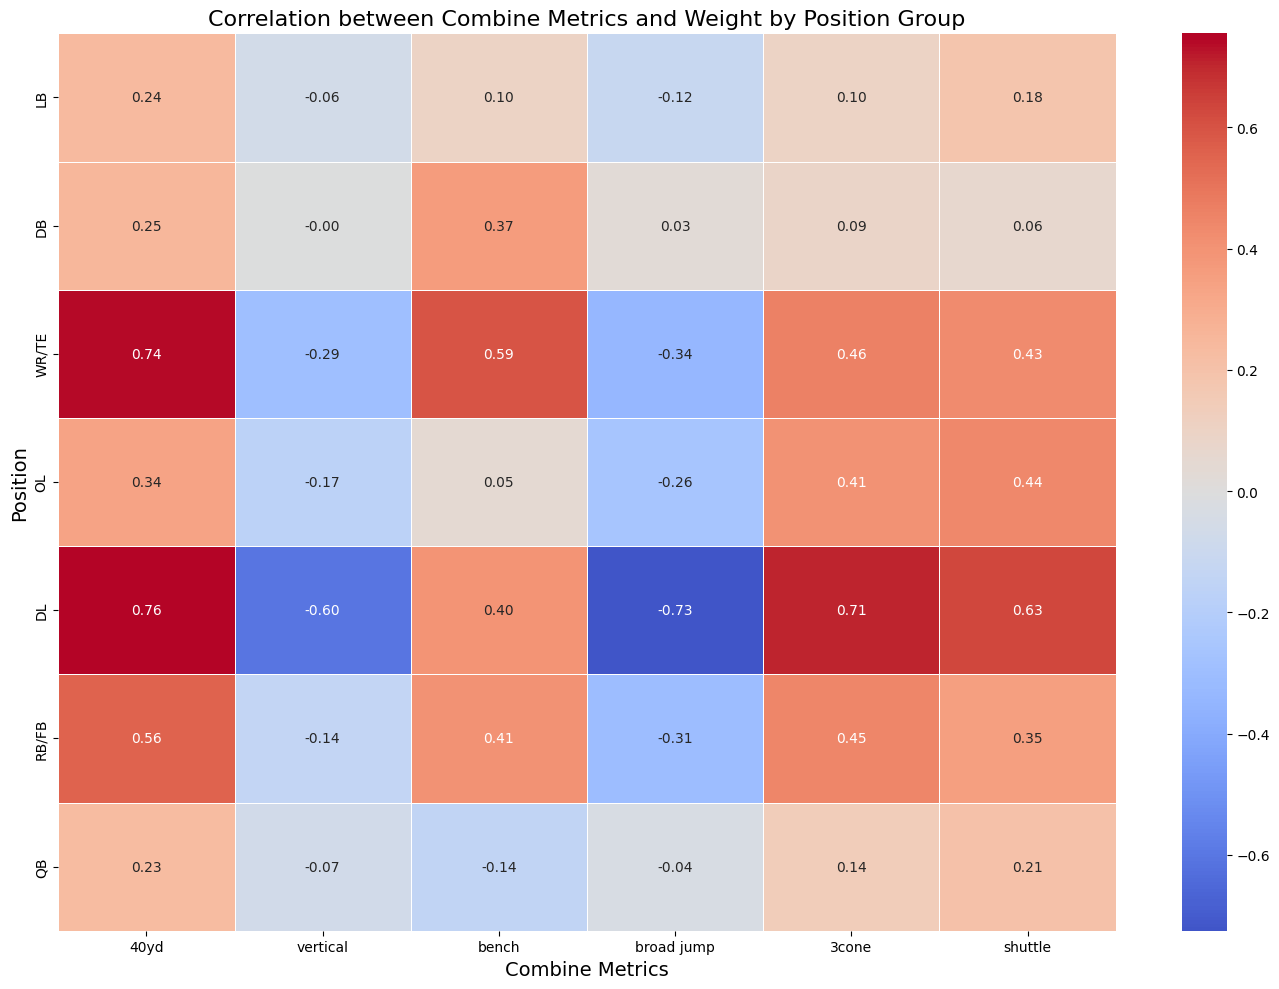

In [ ]:
#call the plotting function to see how combine metrics correlate with weight by grouped position
position_group_corr = plot_position_metric_correlations(
    grouped_df,
    target_col='wt',
    drill_columns=DRILL_COLUMNS,
    positions=list(grouped_df['position_group'].unique()),
    min_position_count=1,
    min_samples=1,
    title='Correlation between Combine Metrics and Weight by Position Group',
    figsize=(14, 10)
)

# Methods


In [ ]:
import statsmodels.api as sm

# Define predictors and target
X = merged_df[["40yd", "vertical", "bench", "broad jump", "3cone", "shuttle", "wt"]]
y = merged_df["wav"]
# add constant
X = sm.add_constant(X)
# fit the regression model
model = sm.OLS(y, X).fit()
# view summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    wav   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     8.600
Date:                Sat, 26 Apr 2025   Prob (F-statistic):           1.61e-10
Time:                        17:19:12   Log-Likelihood:                -21651.
No. Observations:                4830   AIC:                         4.332e+04
Df Residuals:                    4822   BIC:                         4.337e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2971      2.158      1.991      0.0

      Feature      Coef  Lower CI  Upper CI
0        40yd  0.607632  0.012401  1.202863
1    vertical -0.000087 -0.093934  0.093760
2       bench  0.001769 -0.058313  0.061851
3  broad jump -0.008535 -0.035862  0.018793
4       3cone  0.038783 -0.371046  0.448612
5     shuttle  0.015225 -0.680321  0.710771
6          wt  0.045236  0.029469  0.061003


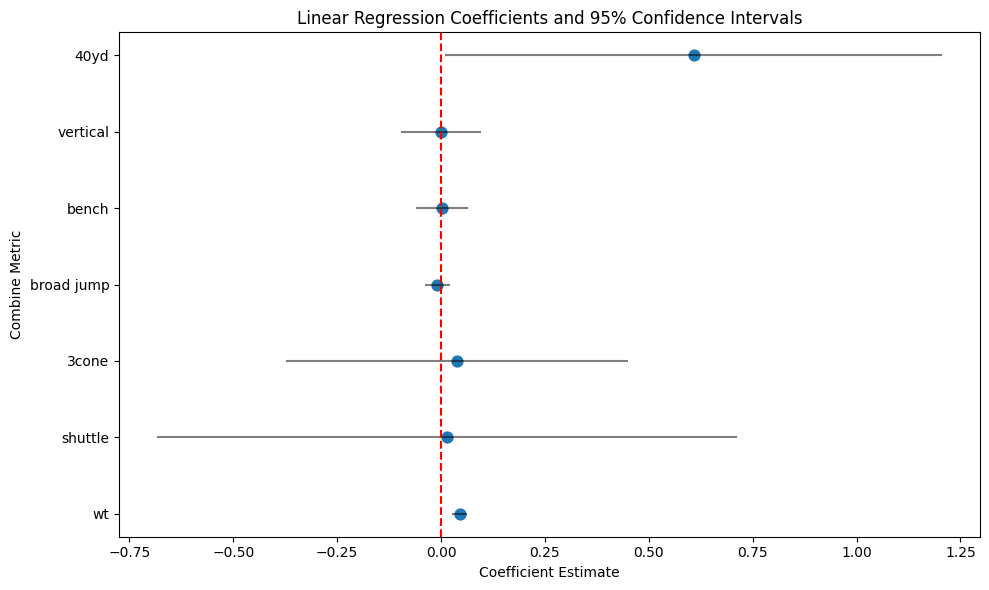

In [ ]:
# add constant
X = sm.add_constant(X)
# fit the regression model
model = sm.OLS(y, X).fit()
# get coef and std err
coefs = model.params
se = model.bse
# calculate the 95% confidence intervals
lower_ci = coefs - 1.96 * se
upper_ci = coefs + 1.96 * se
# combine everything into coef_data
coef_data = pd.DataFrame({
    "Feature": coefs.index,
    "Coef": coefs.values,
    "Lower CI": lower_ci.values,
    "Upper CI": upper_ci.values
})
# remove the const row
coef_data = coef_data[coef_data["Feature"] != "const"].reset_index(drop=True)
# print table
print(coef_data)

# visualization
df = pd.DataFrame(coef_data)
plt.figure(figsize = (10, 6))
sns.pointplot(data = df, x = "Coef", y = "Feature", join = False)
# plot ci for each feature
for i in range(df.shape[0]):
    plt.plot([df["Lower CI"][i], df["Upper CI"][i]], [i, i], color = "black", alpha = 0.5)
# add vertical red line
plt.axvline(0, color = "red", linestyle = "--")
# titles and labels
plt.title("Linear Regression Coefficients and 95% Confidence Intervals")
plt.xlabel("Coefficient Estimate")
plt.ylabel("Combine Metric")
# layout and showing plot
plt.tight_layout()
plt.show()

F-statistic: 295.25004759518316
p-value: 5e-323


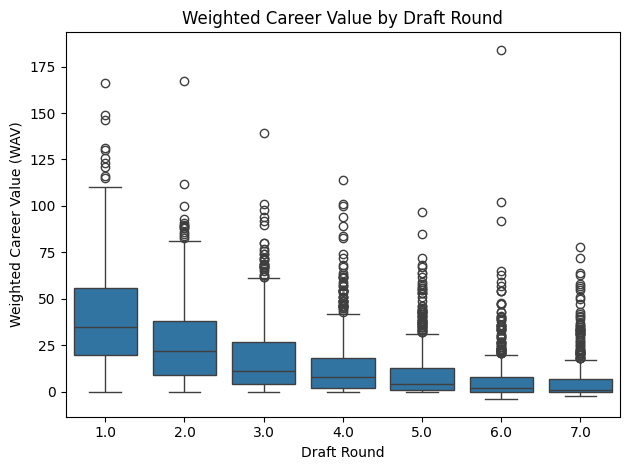

In [ ]:
import scipy.stats as stats
import pandas as pd

# group combine performance by draft round
anova_groups = [group["wav"].values for name, group in merged_df.groupby("rnd")]
# one way anova
f_stat, p_value = stats.f_oneway(*anova_groups)
#print f stat and p value
print("F-statistic:", f_stat)
print("p-value:", p_value)

#visualization
sns.boxplot(x = "rnd", y = "wav", data = merged_df)
plt.title("Weighted Career Value by Draft Round")
plt.xlabel("Draft Round")
plt.ylabel("Weighted Career Value (WAV)")
plt.tight_layout()
plt.show()

In [ ]:
# summary statistics
def calculate_whiskers(group):
    q1 = group.quantile(0.25)
    q3 = group.quantile(0.75)
    iqr = q3 - q1
    lower_whisker = group[group >= (q1 - 1.5 * iqr)].min()
    upper_whisker = group[group <= (q3 + 1.5 * iqr)].max()
    return pd.Series({
        "Q1": q1,
        "Median": group.median(),
        "Q3": q3,
        "Lower Whisker": lower_whisker,
        "Upper Whisker": upper_whisker
    })

summary_stats = merged_df.groupby("rnd")["wav"].apply(calculate_whiskers).round(2)
print(summary_stats)

rnd               
1.0  Q1                20.00
     Median            35.00
     Q3                56.00
     Lower Whisker      0.00
     Upper Whisker    110.00
2.0  Q1                 9.00
     Median            22.00
     Q3                38.00
     Lower Whisker      0.00
     Upper Whisker     81.00
3.0  Q1                 4.00
     Median            11.00
     Q3                27.00
     Lower Whisker      0.00
     Upper Whisker     61.00
4.0  Q1                 2.00
     Median             8.00
     Q3                18.25
     Lower Whisker      0.00
     Upper Whisker     42.00
5.0  Q1                 1.00
     Median             4.00
     Q3                13.00
     Lower Whisker      0.00
     Upper Whisker     31.00
6.0  Q1                 0.00
     Median             2.00
     Q3                 8.00
     Lower Whisker     -4.00
     Upper Whisker     20.00
7.0  Q1                 0.00
     Median             1.00
     Q3                 7.00
     Lower Whisker     -

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

#create copy of merged_df
grouped_mdf = merged_df.copy()

#create a new column called 'position_group' by mapping each position to its group
for group, position in position_groups.items():
    grouped_mdf.loc[grouped_mdf['pos_combine'].isin(position), 'position_group'] = group

#select X features
features = DRILL_COLUMNS + ['ht','wt']

values = {}

for name, group in grouped_mdf.groupby('position_group'):
  # Scale the features
  X = StandardScaler().fit_transform(group[features])

  # create list to store inertias
  inertias = []
  distortions = []

  # find ideal K
  #   fit K-means model for 1 to 7 clusters
  #   add inertias to dictionary
  for i in range(1,8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    distortions.append(sum(np.min(cdist(X, kmeans.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])

  values[name] = [inertias, distortions]

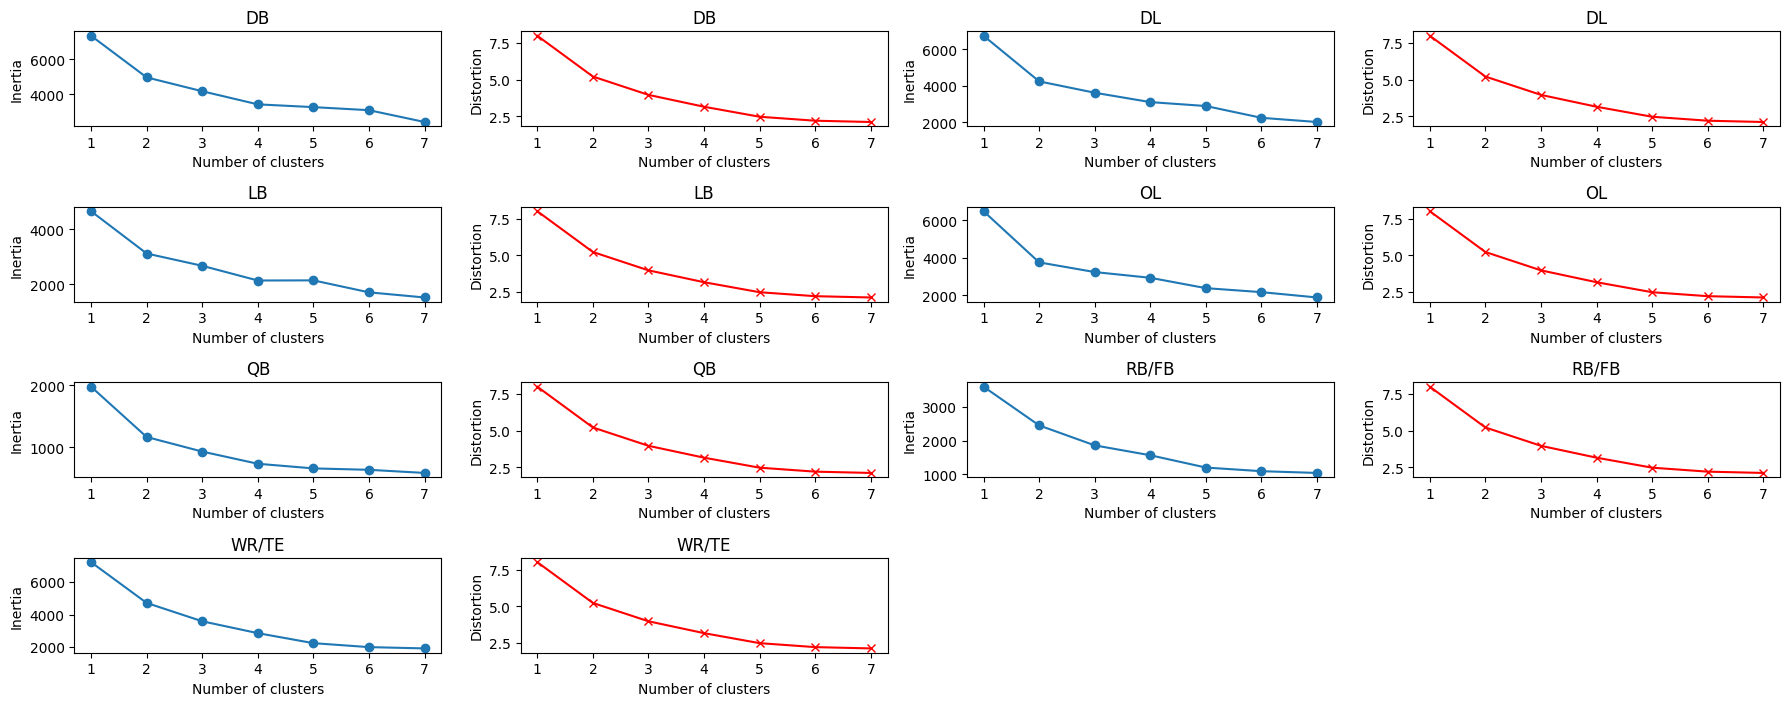

In [ ]:
# visualize elbow method for inertia and distortion

plt.figure(figsize=(18, 12))
#loop through each position group and its cluster
for i, (key, value) in enumerate(values.items()):
    #adjust i for every other odd number
    i = i * 2 + 1

    #create a 7-row, 4-column grid of subplots and select the current one
    plt.subplot(7, 4, i)

    # separate inertias and distortions
    inertias = value[0]
    distortians = value[1]

    #plot inertia for group
    plt.plot(range(1,8), inertias, marker='o')
    plt.title(f"{key}")
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')

    #select next subplot in 7-row, 4-column grid of subplots
    plt.subplot(7,4,i+1)

    #plot distortion for group
    plt.plot(range(1,8), distortions, marker='x', color = 'red')
    plt.title(f"{key}")
    plt.xlabel('Number of clusters')
    plt.ylabel('Distortion')

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

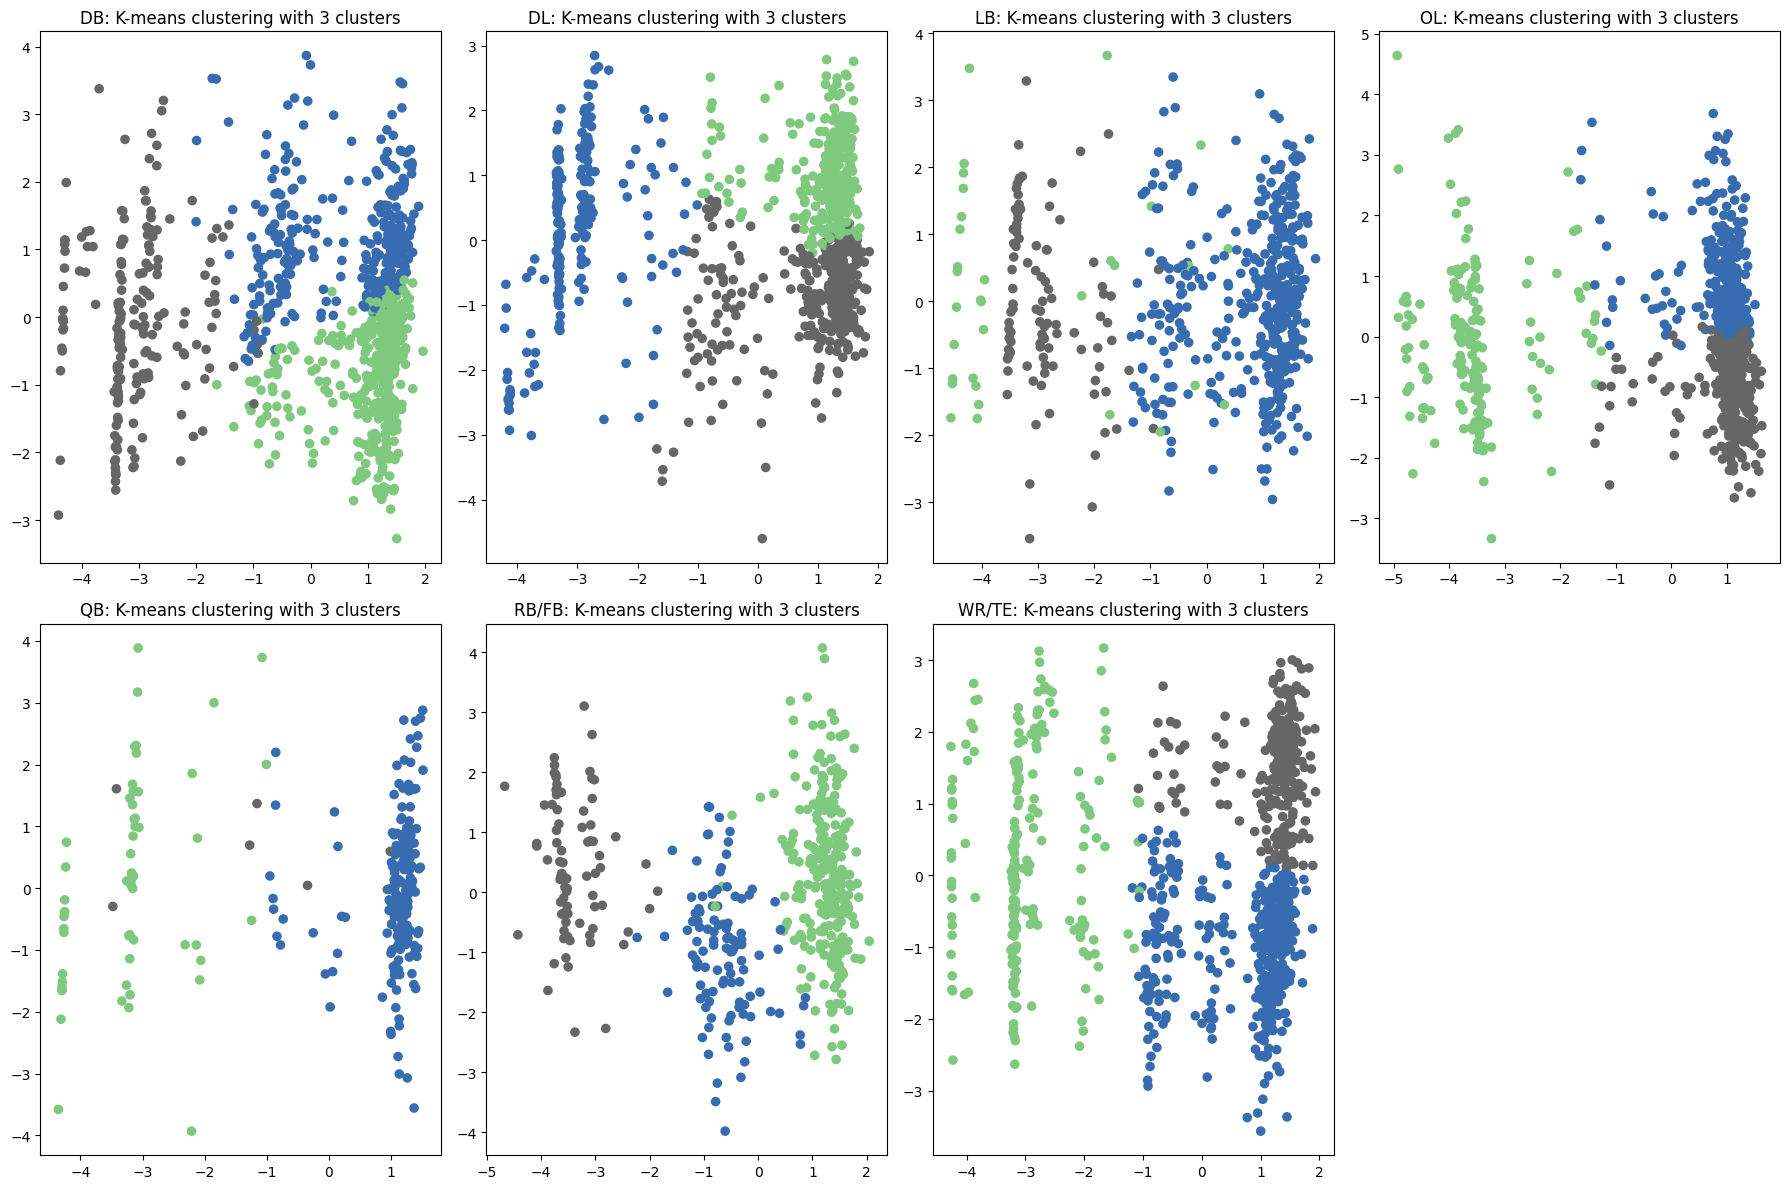

In [ ]:
from matplotlib import colormaps
# kmeans clustering by position group --- working on this, will come back later
k = 3

plt.figure(figsize=(18, 12))
#loop through each position group and its cluster
for i, (name, group) in enumerate(grouped_mdf.groupby('position_group'), 1):
  # scale the features
  X = StandardScaler().fit_transform(group[features])

  # build and fit kmeans model
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
  clusters = kmeans.fit_predict(X)

  # run PCA to reduce dimensions
  reduced_data = PCA(n_components=2).fit_transform(X)
  results = pd.DataFrame(reduced_data,columns=['pca1','pca2'])

  #create a 2-row, 4-column grid of subplots and select the current one
  plt.subplot(2, 4, i)

  # plot scatterplot of pca with color from cluster
  plt.scatter(results['pca1'], results['pca2'], c=clusters, cmap='Accent', s=35)
  plt.title(f"{name}: K-means clustering with {k} clusters")

#adjust layout
plt.tight_layout()

#show the plot
plt.show()

# Results

In [ ]:
# create regression summary table
summary_table = pd.DataFrame({
    "Feature": model.params.index,
    "Coef": model.params.values,
    "P-value": model.pvalues.values,
    "Lower CI": lower_ci.values,
    "Upper CI": upper_ci.values
}).round(3)

# drop constant row
summary_table = summary_table[summary_table["Feature"] != "const"].reset_index(drop=True)

# r squared
r_squared = model.rsquared
print("R-squared:", round(r_squared, 3))

# print summary table
print(summary_table)

R-squared: 0.012
      Feature   Coef  P-value  Lower CI  Upper CI
0        40yd  0.608    0.045     0.012     1.203
1    vertical -0.000    0.999    -0.094     0.094
2       bench  0.002    0.954    -0.058     0.062
3  broad jump -0.009    0.540    -0.036     0.019
4       3cone  0.039    0.853    -0.371     0.449
5     shuttle  0.015    0.966    -0.680     0.711
6          wt  0.045    0.000     0.029     0.061


In [ ]:
summary_table.to_csv("regression_summary.csv", index=False)

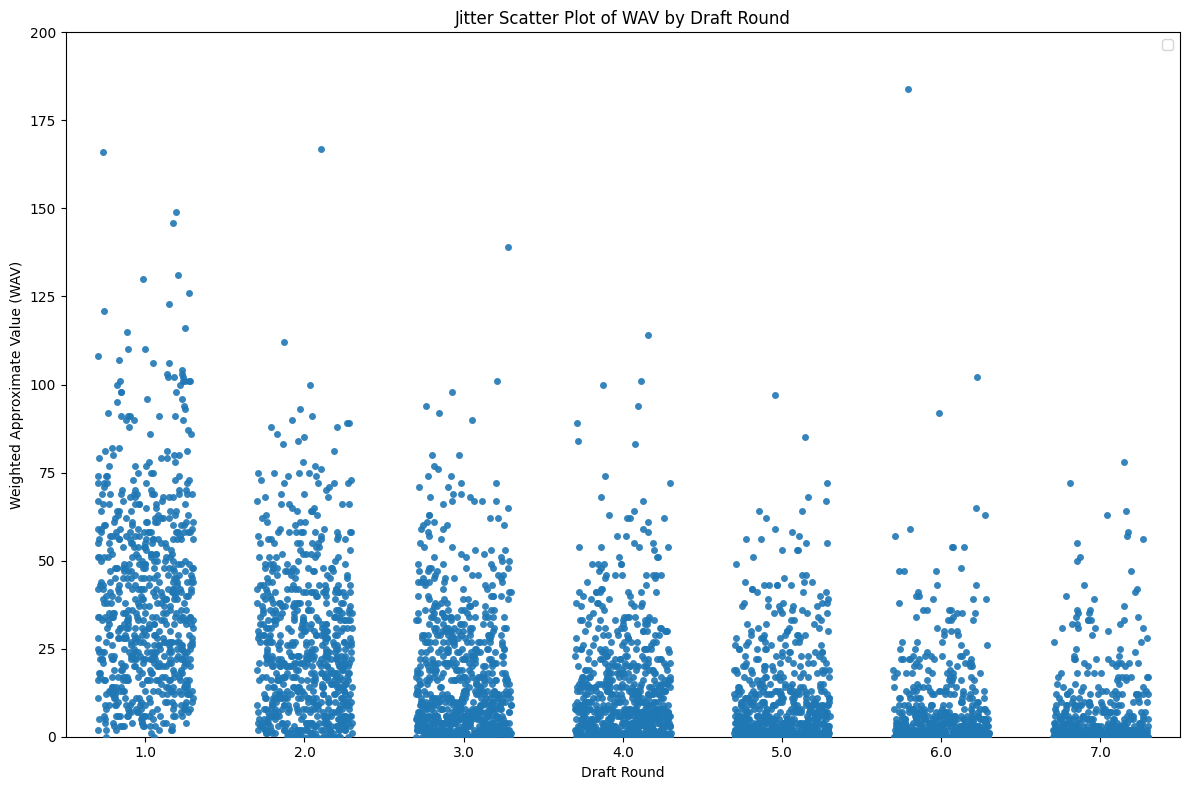

In [ ]:
# jitter plot - anova
plt.figure(figsize=(12,8))
plt.ylim(0, 200)
sns.stripplot(data = merged_df, x = "rnd", y = "wav", jitter = 0.3, alpha = 0.9)
plt.title("Jitter Scatter Plot of WAV by Draft Round")
plt.xlabel("Draft Round")
plt.ylabel("Weighted Approximate Value (WAV)")
#plt.axhline(17.61, color = "red", linestyle = "-", label = "Mean WAV: 17.61")
plt.legend()
#plt.grid(False)
plt.tight_layout()
plt.show()

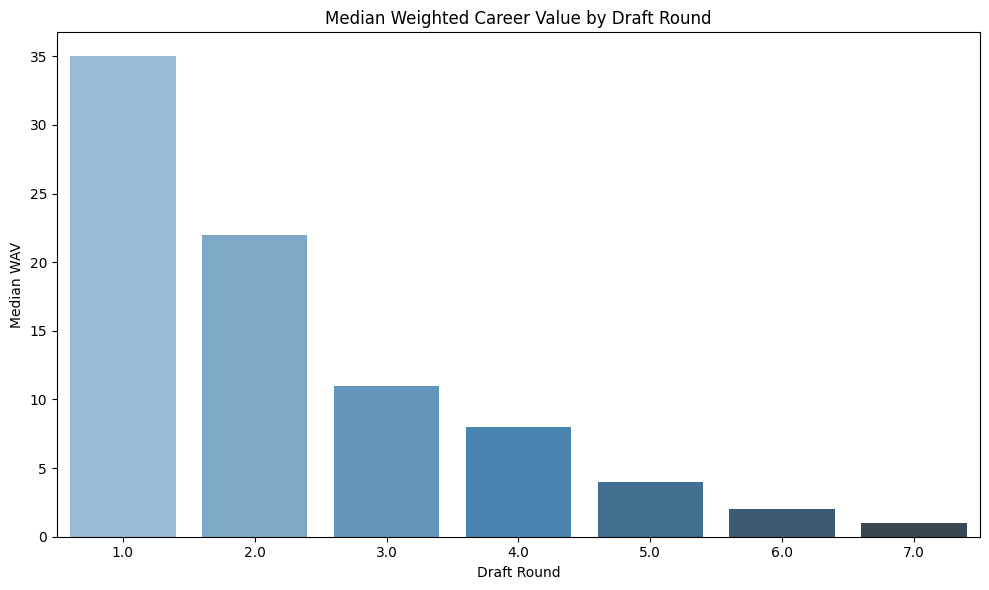

In [ ]:
# calculate medians
median_wav = merged_df.groupby("rnd")["wav"].median().reset_index()

# histogram of median wav by round
plt.figure(figsize=(10, 6))
sns.barplot(data = median_wav, x = "rnd", y = "wav", palette = "Blues_d")
plt.title("Median Weighted Career Value by Draft Round")
plt.xlabel("Draft Round")
plt.ylabel("Median WAV")
plt.tight_layout()
plt.show()

In [ ]:
# calculate mean wav
overall_mean_wav = merged_df["wav"].mean()
print(f"\nOverall Mean WAV: {overall_mean_wav:.2f}")
# calculate median wav
overall_median_wav = merged_df["wav"].median()
print(f"Overall Median WAV: {overall_median_wav:.2f}")
#calculate only round 6 mean wav
round_6_data = merged_df[merged_df["rnd"] == 6]
mean_round_6 = round_6_data["wav"].mean()
print(f"Mean WAV for Round 6: {mean_round_6:.2f}")


Overall Mean WAV: 17.61
Overall Median WAV: 9.00
Mean WAV for Round 6: 7.27


In [ ]:
# Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

#create copy of merged_df
grouped_mdf = merged_df.copy()

#create a new column called 'position_group' by mapping each position to its group
for group, position in position_groups.items():
    grouped_mdf.loc[grouped_mdf['pos_combine'].isin(position), 'position_group'] = group

#select X features
features = DRILL_COLUMNS + ['ht','wt']

results = {}

for name, group in grouped_mdf.groupby('position_group'):
  # Scale the features and run PCA to reduce dimensions
  scaled_features = StandardScaler().fit_transform(group[features])
  pca = PCA(n_components = 2)
  X_principal = pca.fit_transform(scaled_features)
  X_principal = pd.DataFrame(data = X_principal, columns = ['P1', 'P2'])

  # Apply DBSCAN
  dbscan = DBSCAN(eps=.5, min_samples=20)
  clusters = dbscan.fit(X_principal[['P1', 'P2']])

  # Add clusters and X to results dictionary
  X = X_principal
  results[name] = [clusters, X]

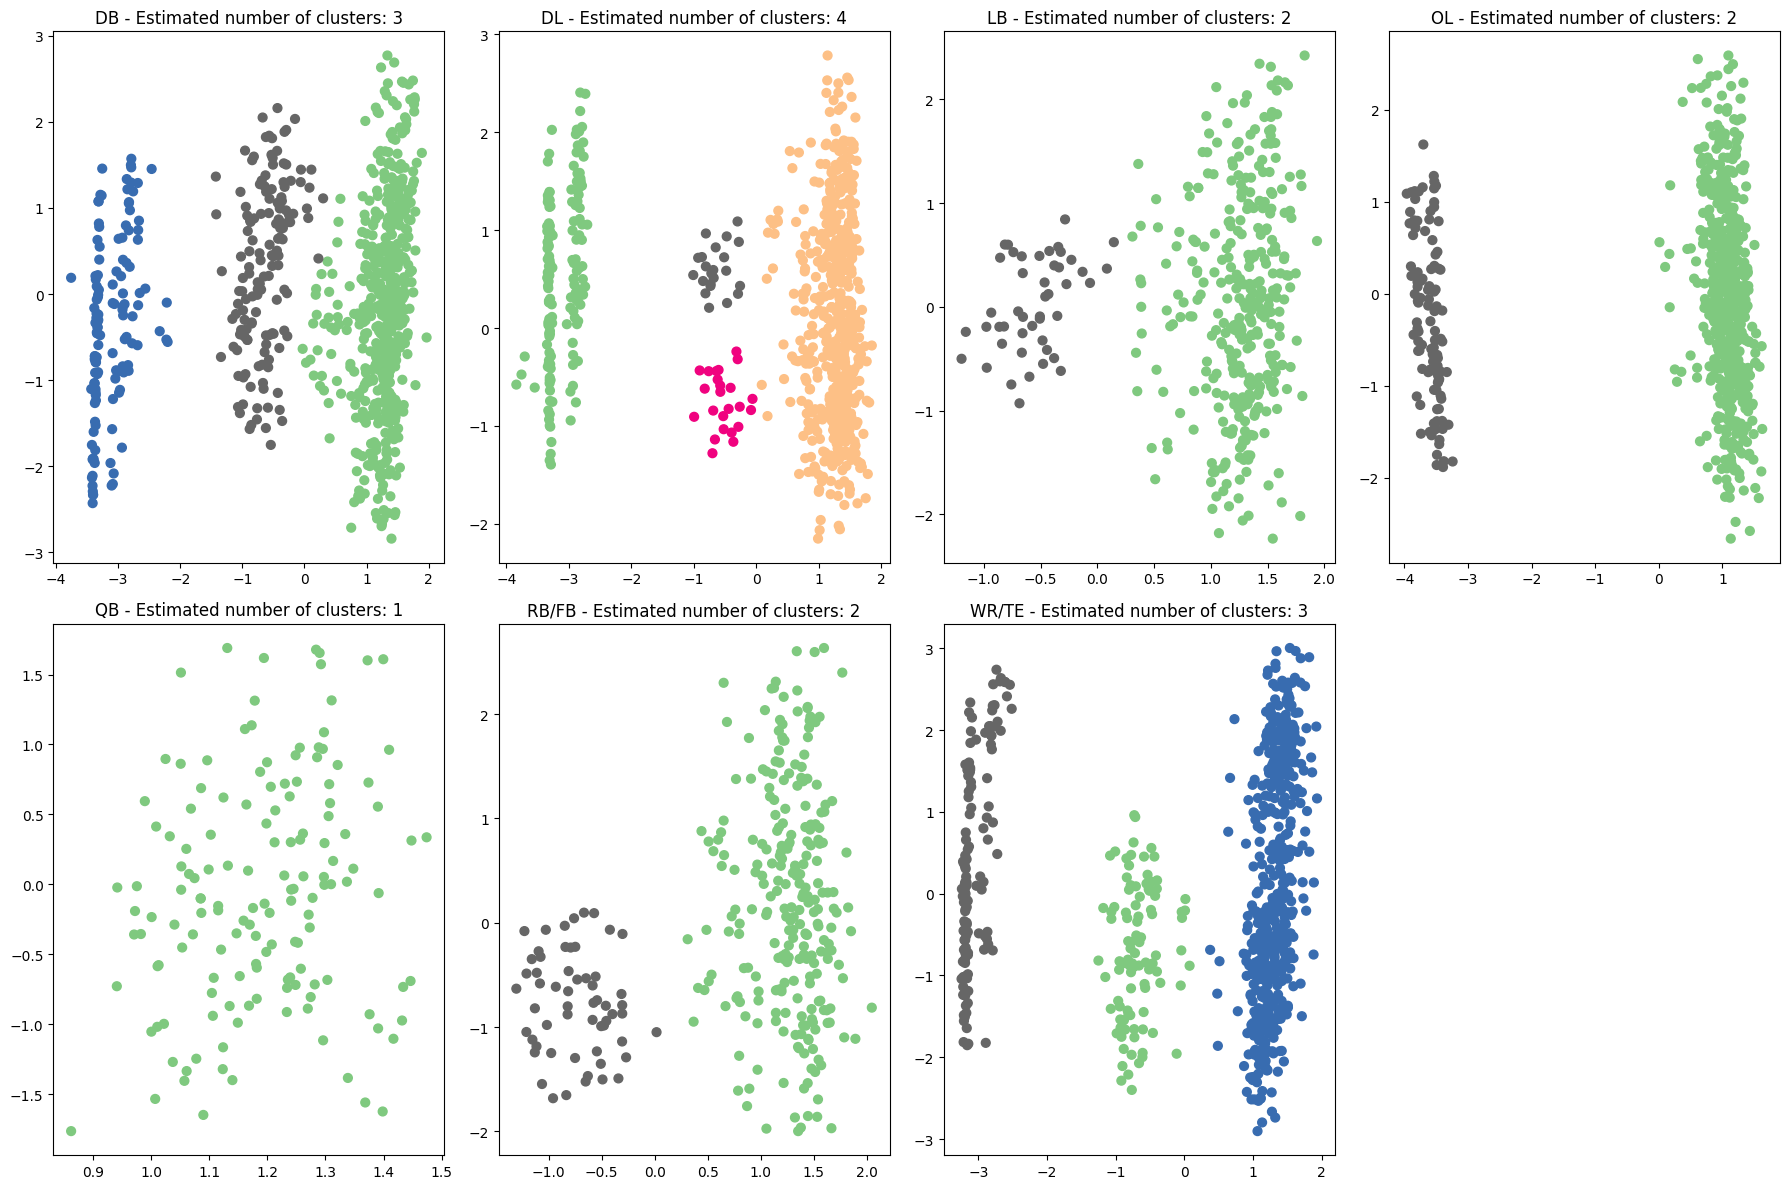

In [ ]:
plt.figure(figsize=(18, 12))

#loop through each position group and its cluster
for i, (key, value) in enumerate(results.items(), start=1):
    #create a 2-row, 4-column grid of subplots and select the current one
    plt.subplot(2, 4, i)

    # get clusters and X from value
    X = value[1]
    db = value[0]

    # get cluster details
    labels = db.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

    # remove values classified -1
    X = X[labels != -1]
    labels_cleaned = [x for x in labels if x != -1]

    # plot scatterplot of principal componenents colored by cluster
    plt.scatter(X['P1'], X['P2'], c=labels_cleaned, cmap='Accent', s=40)

    plt.title(f"{key} - Estimated number of clusters: {n_clusters_}")

#adjust layout
plt.tight_layout()

#show the plot
plt.show()